## Dataset Preparation

In [ ]:
!pip install transformers
!pip install -q transformers datasets
!pip install transformers[torch]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 18.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 27.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 36.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.3/519.3 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.2/251.2 kB 3.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
import torch
import torch.nn as nn
import numpy as np
import ast
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from scipy.stats import pearsonr
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BertTokenizerFast, BertForSequenceClassification
from transformers import EvalPrediction
import os
from datasets import load_dataset
import seaborn as sns

In [ ]:
if torch.cuda.is_available():
    device = torch.cuda.get_device_name(0)
    print('GPU device:', device)
else:
    print('No GPU available.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

No GPU available.


In [ ]:
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/My Drive/MSc Project/fabsa.csv')


Convert the representation of 'labels' and split the data

In [ ]:
# Convert the string representation of lists in 'labels' column to actual list
df['labels'] = df['labels'].apply(ast.literal_eval)

# Now you can generate the unique list of labels as before
labels = list(set([label for sublist in df['labels'].tolist() for label in sublist]))
id2label = {idx: label for idx, label in enumerate(labels)}
label2id = {label: idx for idx, label in enumerate(labels)}

Create hugging face data set

In [ ]:
# convert data CSV file into hugging face data set
def create_hf_dataset(augmented_train_csv_path):
    # Load the augmented data CSV file and validation CSV file
    augmented_df = pd.read_csv(augmented_train_csv_path, converters={'labels': ast.literal_eval})
    val_df = pd.read_csv("/content/gdrive/My Drive/MSc Project/val_df.csv", converters={'labels': ast.literal_eval})
    # Convert the pandas DataFrame to a Hugging Face Dataset
    train_dataset = Dataset.from_pandas(augmented_df)
    val_dataset = Dataset.from_pandas(val_df)

    # Combine them into a DatasetDict
    dataset = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset
    })

    return dataset

In [ ]:
all_datasets = {}

Create original hugging face dataset

*   Original, 60% augmented (EDA, Backtranslation - Spanish, Korean)



In [ ]:
dataset_key = "train_original"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/train_df.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "train_eda_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/train_eda_60.0.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "train_bt_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/backtrans_60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "train_bt_ko_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/backtrans_ko_60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

Create 1% Subset hugging face dataset


*   1% subset and 60% augmented subset (EDA, Backtranslation - Spanish, Korean)



In [ ]:
dataset_key = "subset01_original"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/train_subset.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset01_eda_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset_eda_60.0.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset01_bt_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset_backtrans_60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset01_bt_ko_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset_backtrans_ko60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

Create 5% Subset hugging face dataset


*   5% subset and 60% augmented subset (EDA, Backtranslation - Spanish, Korean)


In [ ]:
dataset_key = "original_subset05"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/train_subset5.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset05_eda_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset5_eda_60.0.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset05_bt_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset5_backtrans_60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset05_bt_ko_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset05_backtrans_ko60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

Create 10% Subset hugging face dataset


*   10% subset and 60% augmented subset (EDA, Backtranslation - Spanish, Korean)


In [ ]:
dataset_key = "subset10_original"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/train_subset10.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset10_eda_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset10_eda_60.0.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset10_bt_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset10_backtrans_60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset10_bt_ko_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset10_backtrans_ko60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

Create 20% Subset hugging face dataset


*   20% subset and 60% augmented subset (EDA, Backtranslation - Spanish, Korean)


In [ ]:
dataset_key = "subset20_original"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/train_subset20.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset20_eda_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset20_eda_60.0.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset20_bt_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset20_backtrans_60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset20_bt_ko_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset20_backtrans_ko60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

Create 30% Subset hugging face dataset


*   30% subset and 60% augmented subset (EDA, Backtranslation - Spanish, Korean)


In [ ]:
dataset_key = "subset30_original"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/train_subset30.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset30_eda_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset30_eda_60.0.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset30_bt_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset30_backtrans_60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

In [ ]:
dataset_key = "subset30_bt_ko_60perc"
train_dataset_path = "/content/gdrive/My Drive/MSc Project/subset30_backtrans_ko60.csv"  # Provide the path to the augmented data CSV file
dataset = create_hf_dataset(train_dataset_path)
all_datasets[dataset_key] = dataset

## Bert-base-uncased


##Original

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels

    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro', zero_division=1)
    f1_per_label = f1_score(y_true=y_true, y_pred=y_pred, average=None, zero_division=1)
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)

    return f1_micro_average, roc_auc, accuracy, f1_per_label

def compute_metrics(p: EvalPrediction):
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(p.predictions, p.label_ids)

    return {
        "eval_f1": f1_micro,
        "eval_roc_auc": roc_auc,
        "eval_accuracy": accuracy,
    }


# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key):
    print(f"Training with {dataset_key} data ...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bertbase-finetuned-{dataset_key}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate= 0.00005,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
    )

    trainer.train()
    result = trainer.evaluate()

    # Get predictions and labels using the predict method
    predictions_output = trainer.predict(encoded_dataset["validation"])

    # Extract predictions and labels from the output
    predictions = predictions_output.predictions
    label_ids = predictions_output.label_ids

    # Compute the per-label F1 scores using the predictions and labels
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(predictions, label_ids)


    # Save the per-label results
    per_label_results_df = pd.DataFrame({'label': labels, 'f1_score': f1_per_label.tolist()})
    per_label_results_df.to_csv(f'/content/gdrive/My Drive/MSc Project/bertbase_{dataset_key}_per_label_results.csv', index=False)


    print(f"Results with {dataset_key}: f1_micro: {result['eval_f1']}, roc_auc: {result['eval_roc_auc']}, accuracy: {result['eval_accuracy']}")

    return {'eval_f1': result['eval_f1'], 'eval_roc_auc': result['eval_roc_auc'], 'eval_accuracy': result['eval_accuracy']}

In [ ]:
# Initialize the DataFrame
original_bertbase = pd.DataFrame(columns=['dataset_key', 'eval_f1', 'eval_roc_auc', 'eval_accuracy'])

In [ ]:
for dataset_key in ["train_original", "train_eda_60perc", "train_bt_60perc", "train_bt_ko_60perc"]:
    dataset = all_datasets[dataset_key]
    result = train_and_evaluate_model(dataset, dataset_key)

    # Append results to the DataFrame
    original_bertbase = original_bertbase.append({
        'dataset_key': dataset_key,
        'eval_f1': result['eval_f1'],
        'eval_roc_auc': result['eval_roc_auc'],
        'eval_accuracy': result['eval_accuracy'],
    }, ignore_index=True)

    # Save the overall results DataFrame to the CSV file
    original_bertbase.to_csv('/content/gdrive/My Drive/MSc Project/original_bertbase.csv', index=False)

    # Remove the folder after processing due to insufficient disk space
    folder_path = f"/content/bertbase-finetuned-{dataset_key}"
    !rm -r $folder_path

Training with train_original data ...


Map:   0%|          | 0/7401 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.160700,0.089432,0.618238,0.748073,0.345414
2,0.077200,0.071666,0.719483,0.818936,0.472108
3,0.056100,0.067655,0.737322,0.834935,0.496061
4,0.041100,0.063599,0.766017,0.863127,0.518437
5,0.029400,0.064124,0.774057,0.870357,0.522534
6,0.021900,0.064860,0.776010,0.873515,0.530098
7,0.016500,0.067370,0.775776,0.876859,0.530098
8,0.012700,0.068227,0.782656,0.881161,0.536401
9,0.010300,0.067666,0.782361,0.875072,0.542074
10,0.008600,0.068326,0.784909,0.880076,0.543965


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.096200,0.078006,0.686246,0.792499,0.435865
2,0.060000,0.064321,0.752235,0.844847,0.518437
3,0.040600,0.066945,0.761255,0.867719,0.515600
4,0.027000,0.066345,0.773450,0.874576,0.525370
5,0.016800,0.069646,0.774991,0.880166,0.532934
6,0.011900,0.071443,0.779618,0.877027,0.539868
7,0.009000,0.074271,0.786048,0.884664,0.549007
8,0.006300,0.076992,0.785592,0.883814,0.548377
9,0.004800,0.077688,0.791205,0.892392,0.552789
10,0.003600,0.078506,0.790481,0.888730,0.555941


Results with train_bt_ko_60perc: f1_micro: 0.7912048940508911, roc_auc: 0.8923920873043295, accuracy: 0.5527891585250552


<ipython-input-40-accf45bbaf0b>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  original_bertbase = original_bertbase.append({


In [ ]:
original_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,train_original,0.784909,0.880076,0.543965
1,train_eda_60perc,0.784391,0.885377,0.540498
2,train_bt_60perc,0.790726,0.892854,0.551844
3,train_bt_ko_60perc,0.791205,0.892392,0.552789


## 1%

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels

    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro', zero_division=1)
    f1_per_label = f1_score(y_true=y_true, y_pred=y_pred, average=None, zero_division=1)
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)

    return f1_micro_average, roc_auc, accuracy, f1_per_label

def compute_metrics(p: EvalPrediction):
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(p.predictions, p.label_ids)

    return {
        "eval_f1": f1_micro,
        "eval_roc_auc": roc_auc,
        "eval_accuracy": accuracy,
    }


# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key):
    print(f"Training with {dataset_key} data ...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bertbase-finetuned-{dataset_key}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=1e-6,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
    )

    trainer.train()
    result = trainer.evaluate()

    # Get predictions and labels using the predict method
    predictions_output = trainer.predict(encoded_dataset["validation"])

    # Extract predictions and labels from the output
    predictions = predictions_output.predictions
    label_ids = predictions_output.label_ids

    # Compute the per-label F1 scores using the predictions and labels
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(predictions, label_ids)


    # Save the per-label results
    per_label_results_df = pd.DataFrame({'label': labels, 'f1_score': f1_per_label.tolist()})
    per_label_results_df.to_csv(f'/content/gdrive/My Drive/MSc Project/bertbase_{dataset_key}_per_label_results.csv', index=False)


    print(f"Results with {dataset_key}: f1_micro: {result['eval_f1']}, roc_auc: {result['eval_roc_auc']}, accuracy: {result['eval_accuracy']}")

    return {'eval_f1': result['eval_f1'], 'eval_roc_auc': result['eval_roc_auc'], 'eval_accuracy': result['eval_accuracy']}

In [ ]:
# Load  the Dataframe
subset01_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/subset01_bertbase.csv')

In [ ]:
# Initialize the DataFrame
subset01_bertbase = pd.DataFrame(columns=['dataset_key', 'eval_f1', 'eval_roc_auc', 'eval_accuracy'])

In [ ]:
for dataset_key in ["subset01_original", "subset01_eda_60perc", "subset01_bt_60perc", "subset01_bt_ko_60perc"]:
    dataset = all_datasets[dataset_key]
    result = train_and_evaluate_model(dataset, dataset_key)

    # Append results to the DataFrame
    subset01_bertbase = subset01_bertbase.append({
        'dataset_key': dataset_key,
        'eval_f1': result['eval_f1'],
        'eval_roc_auc': result['eval_roc_auc'],
        'eval_accuracy': result['eval_accuracy'],
    }, ignore_index=True)

    # Save the overall results DataFrame to the CSV file
    subset01_bertbase.to_csv('/content/gdrive/My Drive/MSc Project/subset01_bertbase.csv', index=False)

    # Remove the folder after processing due to insufficient disk space
    folder_path = f"/content/bertbase-finetuned-{dataset_key}"
    !rm -r $folder_path

Training with subset01_original data ...


Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.734384,0.080046,0.472567,0.000000
2,No log,0.730240,0.080984,0.475533,0.000000
3,No log,0.726576,0.082134,0.479097,0.000000
4,No log,0.723402,0.083288,0.482610,0.000000
5,No log,0.720741,0.084339,0.485829,0.000000
6,No log,0.718584,0.085604,0.489626,0.000000
7,No log,0.716910,0.086022,0.490974,0.000000
8,No log,0.715687,0.086838,0.493403,0.000000
9,No log,0.714931,0.087156,0.494369,0.000000
10,No log,0.714657,0.087349,0.494942,0.000000


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.701841,0.112486,0.570439,0.000000
2,No log,0.695390,0.111441,0.565883,0.000000
3,No log,0.689398,0.108802,0.556893,0.000000
4,No log,0.684143,0.105914,0.547753,0.000000
5,No log,0.679683,0.103874,0.541619,0.000000
6,No log,0.676038,0.102272,0.536982,0.000000
7,No log,0.673199,0.100610,0.532376,0.000000
8,No log,0.671206,0.099415,0.529149,0.000000
9,No log,0.670009,0.098619,0.527031,0.000000
10,No log,0.669610,0.098431,0.526535,0.000000


Results with subset01_bt_ko_60perc: f1_micro: 0.11248644741597398, roc_auc: 0.570439026808861, accuracy: 0.0


<ipython-input-61-d200e5a79559>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subset01_bertbase = subset01_bertbase.append({


In [ ]:
subset01_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,subset01_original,0.087349,0.494942,0.0
1,subset01_eda_60perc,0.112718,0.571285,0.0
2,subset01_bt_60perc,0.112786,0.571410,0.0
3,subset01_bt_ko_60perc,0.112486,0.570439,0.0


## 5%

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels

    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro', zero_division=1)
    f1_per_label = f1_score(y_true=y_true, y_pred=y_pred, average=None, zero_division=1)
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)

    return f1_micro_average, roc_auc, accuracy, f1_per_label

def compute_metrics(p: EvalPrediction):
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(p.predictions, p.label_ids)

    return {
        "eval_f1": f1_micro,
        "eval_roc_auc": roc_auc,
        "eval_accuracy": accuracy,
    }


# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key):
    print(f"Training with {dataset_key} data ...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bert-finetuned-{dataset_key}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=7e-5,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
    )

    trainer.train()
    result = trainer.evaluate()

    # Get predictions and labels using the predict method
    predictions_output = trainer.predict(encoded_dataset["validation"])

    # Extract predictions and labels from the output
    predictions = predictions_output.predictions
    label_ids = predictions_output.label_ids

    # Compute the per-label F1 scores using the predictions and labels
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(predictions, label_ids)


    # Save the per-label results
    per_label_results_df = pd.DataFrame({'label': labels, 'f1_score': f1_per_label.tolist()})
    per_label_results_df.to_csv(f'/content/gdrive/My Drive/MSc Project/bertbase_{dataset_key}_per_label_results.csv', index=False)


    print(f"Results with {dataset_key}: f1_micro: {result['eval_f1']}, roc_auc: {result['eval_roc_auc']}, accuracy: {result['eval_accuracy']}")

    return {'eval_f1': result['eval_f1'], 'eval_roc_auc': result['eval_roc_auc'], 'eval_accuracy': result['eval_accuracy']}

In [ ]:
# Initialize the DataFrame
subset05_bertbase = pd.DataFrame(columns=['dataset_key', 'eval_f1', 'eval_roc_auc', 'eval_accuracy'])

In [ ]:
for dataset_key in ["original_subset05", "subset05_eda_60perc", "subset05_bt_60perc"]:
    dataset = all_datasets[dataset_key]
    result = train_and_evaluate_model(dataset, dataset_key)

    # Append results to the DataFrame
    subset05_bertbase = subset05_bertbase.append({
        'dataset_key': dataset_key,
        'eval_f1': result['eval_f1'],
        'eval_roc_auc': result['eval_roc_auc'],
        'eval_accuracy': result['eval_accuracy'],
    }, ignore_index=True)

    # Save the overall results DataFrame to the CSV file
    subset05_bertbase.to_csv('/content/gdrive/My Drive/MSc Project/subset05_bertbase.csv', index=False)

Training with original_subset05 data ...


Map:   0%|          | 0/380 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.156979,0.000000,0.500000,0.000000
2,No log,0.140518,0.000000,0.500000,0.000000
3,0.178100,0.124514,0.396899,0.634243,0.186259
4,0.178100,0.118178,0.415918,0.641892,0.199811
5,0.178100,0.108596,0.514136,0.689342,0.262843
6,0.112800,0.103164,0.543629,0.706807,0.283643
7,0.112800,0.099597,0.571429,0.721254,0.305704
8,0.079800,0.098345,0.577327,0.725015,0.304759
9,0.079800,0.096858,0.594612,0.736695,0.322408
10,0.079800,0.096440,0.598029,0.737561,0.326190


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.151393,0.000000,0.500000,0.000000
2,0.176700,0.129109,0.438444,0.655818,0.209896
3,0.176700,0.116843,0.448190,0.664106,0.220611
4,0.119800,0.105251,0.554327,0.717379,0.292153
5,0.084200,0.099855,0.598103,0.745798,0.319571
6,0.084200,0.095312,0.627820,0.763668,0.351718
7,0.063300,0.094247,0.623082,0.760014,0.349196
8,0.063300,0.092916,0.632054,0.764518,0.358966
9,0.049900,0.092990,0.637576,0.768707,0.364009
10,0.042200,0.092715,0.636763,0.767381,0.366530


Results with subset05_bt_60perc: f1_micro: 0.6375755051031035, roc_auc: 0.7687071432453146, accuracy: 0.36400882445635047


<ipython-input-30-585ed17d4c1c>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subset05_bertbase = subset05_bertbase.append({


In [ ]:
# Load  the Dataframe
subset05_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/subset05_bertbase.csv')

In [ ]:
for dataset_key in ["subset05_bt_ko_60perc"]:
    dataset = all_datasets[dataset_key]
    result = train_and_evaluate_model(dataset, dataset_key)

    # Append results to the DataFrame
    subset05_bertbase = subset05_bertbase.append({
        'dataset_key': dataset_key,
        'eval_f1': result['eval_f1'],
        'eval_roc_auc': result['eval_roc_auc'],
        'eval_accuracy': result['eval_accuracy'],
    }, ignore_index=True)

    # Save the overall results DataFrame to the CSV file
    subset05_bertbase.to_csv('/content/gdrive/My Drive/MSc Project/subset05_bertbase.csv', index=False)

Training with subset05_bt_ko_60perc data ...


Map:   0%|          | 0/608 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.144732,0.001780,0.500418,0.001261
2,0.175700,0.129029,0.399224,0.634946,0.198865
3,0.175700,0.113947,0.476179,0.672789,0.235109
4,0.119300,0.104807,0.568952,0.729615,0.291522
5,0.085900,0.100464,0.573677,0.724212,0.311062
6,0.085900,0.095724,0.605603,0.746647,0.330602
7,0.066700,0.094708,0.610594,0.750381,0.345414
8,0.066700,0.093086,0.616962,0.751298,0.347936
9,0.052800,0.092011,0.631248,0.764383,0.364324
10,0.044200,0.091852,0.630735,0.762605,0.364954


Results with subset05_bt_ko_60perc: f1_micro: 0.6312480352090537, roc_auc: 0.7643828569191035, accuracy: 0.3643239836117239


<ipython-input-67-55e6d2cb8c5c>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subset05_bertbase = subset05_bertbase.append({


In [ ]:
subset05_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,original_subset05,0.598029,0.737561,0.326190
1,subset05_eda_60perc,0.627958,0.762016,0.349196
2,subset05_bt_60perc,0.637576,0.768707,0.364009
3,subset05_bt_ko_60perc,0.631248,0.764383,0.364324


## 10%

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels

    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro', zero_division=1)
    f1_per_label = f1_score(y_true=y_true, y_pred=y_pred, average=None, zero_division=1)
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)

    return f1_micro_average, roc_auc, accuracy, f1_per_label

def compute_metrics(p: EvalPrediction):
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(p.predictions, p.label_ids)

    return {
        "eval_f1": f1_micro,
        "eval_roc_auc": roc_auc,
        "eval_accuracy": accuracy,
    }


# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key):
    print(f"Training with {dataset_key} data ...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bert-finetuned-{dataset_key}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=5e-5,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
    )

    trainer.train()
    result = trainer.evaluate()

    # Get predictions and labels using the predict method
    predictions_output = trainer.predict(encoded_dataset["validation"])

    # Extract predictions and labels from the output
    predictions = predictions_output.predictions
    label_ids = predictions_output.label_ids

    # Compute the per-label F1 scores using the predictions and labels
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(predictions, label_ids)


    # Save the per-label results
    per_label_results_df = pd.DataFrame({'label': labels, 'f1_score': f1_per_label.tolist()})
    per_label_results_df.to_csv(f'/content/gdrive/My Drive/MSc Project/bertbase_{dataset_key}_per_label_results.csv', index=False)


    print(f"Results with {dataset_key}: f1_micro: {result['eval_f1']}, roc_auc: {result['eval_roc_auc']}, accuracy: {result['eval_accuracy']}")

    return {'eval_f1': result['eval_f1'], 'eval_roc_auc': result['eval_roc_auc'], 'eval_accuracy': result['eval_accuracy']}

In [ ]:
# Initialize the DataFrame
subset10_bertbase = pd.DataFrame(columns=['dataset_key', 'eval_f1', 'eval_roc_auc', 'eval_accuracy'])

In [ ]:
for dataset_key in ["subset10_original", "subset10_eda_60perc", "subset10_bt_60perc", "subset10_bt_ko_60perc"]:
    dataset = all_datasets[dataset_key]
    result = train_and_evaluate_model(dataset, dataset_key)

    # Append results to the DataFrame
    subset10_bertbase = subset10_bertbase.append({
        'dataset_key': dataset_key,
        'eval_f1': result['eval_f1'],
        'eval_roc_auc': result['eval_roc_auc'],
        'eval_accuracy': result['eval_accuracy'],
    }, ignore_index=True)

    # Save the overall results DataFrame to the CSV file
    subset10_bertbase.to_csv('/content/gdrive/My Drive/MSc Project/subset10_bertbase.csv', index=False)

    # Remove the folder after processing
    folder_path = f"/content/bert-finetuned-{dataset_key}"
    !rm -r $folder_path

Training with subset10_original data ...


Map:   0%|          | 0/750 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,No log,0.142578,0.000000,0.500000,0.000000
2,0.180500,0.119140,0.473290,0.666757,0.240782
3,0.118600,0.108394,0.510893,0.687505,0.256855
4,0.095600,0.100788,0.542890,0.706215,0.287740
5,0.095600,0.094341,0.619957,0.751426,0.346990
6,0.074400,0.091313,0.636230,0.766234,0.364954
7,0.062200,0.089984,0.633969,0.760449,0.375985
8,0.052000,0.086917,0.648397,0.769684,0.386700
9,0.052000,0.086421,0.655578,0.777258,0.399307
10,0.045200,0.086162,0.658341,0.778242,0.398361


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.181500,0.126731,0.389226,0.627158,0.190671
2,0.121500,0.107198,0.497182,0.681853,0.253073
3,0.095400,0.095281,0.598989,0.739588,0.329341
4,0.081600,0.091213,0.624672,0.760995,0.346990
5,0.054100,0.087789,0.647379,0.771525,0.381658
6,0.045300,0.085463,0.661356,0.784434,0.398361
7,0.038400,0.085131,0.667946,0.790399,0.410652
8,0.031200,0.084070,0.685821,0.805893,0.423259
9,0.028700,0.084000,0.683280,0.802185,0.424519
10,0.023800,0.083536,0.684455,0.804032,0.425150


Results with subset10_bt_ko_60perc: f1_micro: 0.6858211158122601, roc_auc: 0.8058931409768425, accuracy: 0.42325874566656163


<ipython-input-71-5a51ddd64e71>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subset10_bertbase = subset10_bertbase.append({


In [ ]:
subset10_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,subset10_original,0.658341,0.778242,0.398361
1,subset10_eda_60perc,0.691321,0.807875,0.420737
2,subset10_bt_60perc,0.695000,0.812955,0.432714
3,subset10_bt_ko_60perc,0.685821,0.805893,0.423259


## 20%

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels

    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro', zero_division=1)
    f1_per_label = f1_score(y_true=y_true, y_pred=y_pred, average=None, zero_division=1)
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)

    return f1_micro_average, roc_auc, accuracy, f1_per_label

def compute_metrics(p: EvalPrediction):
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(p.predictions, p.label_ids)

    return {
        "eval_f1": f1_micro,
        "eval_roc_auc": roc_auc,
        "eval_accuracy": accuracy,
    }


# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key):
    print(f"Training with {dataset_key} data ...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bert-finetuned-{dataset_key}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=5e-5,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
    )

    trainer.train()
    result = trainer.evaluate()

    # Get predictions and labels using the predict method
    predictions_output = trainer.predict(encoded_dataset["validation"])

    # Extract predictions and labels from the output
    predictions = predictions_output.predictions
    label_ids = predictions_output.label_ids

    # Compute the per-label F1 scores using the predictions and labels
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(predictions, label_ids)


    # Save the per-label results
    per_label_results_df = pd.DataFrame({'label': labels, 'f1_score': f1_per_label.tolist()})
    per_label_results_df.to_csv(f'/content/gdrive/My Drive/MSc Project/bertbase_{dataset_key}_per_label_results.csv', index=False)


    print(f"Results with {dataset_key}: f1_micro: {result['eval_f1']}, roc_auc: {result['eval_roc_auc']}, accuracy: {result['eval_accuracy']}")

    return {'eval_f1': result['eval_f1'], 'eval_roc_auc': result['eval_roc_auc'], 'eval_accuracy': result['eval_accuracy']}

In [ ]:
# Initialize the DataFrame
subset20_bertbase = pd.DataFrame(columns=['dataset_key', 'eval_f1', 'eval_roc_auc', 'eval_accuracy'])

In [ ]:
for dataset_key in ["subset20_original", "subset20_eda_60perc", "subset20_bt_60perc"]:
    dataset = all_datasets[dataset_key]
    result = train_and_evaluate_model(dataset, dataset_key)

    # Append results to the DataFrame
    subset20_bertbase = subset20_bertbase.append({
        'dataset_key': dataset_key,
        'eval_f1': result['eval_f1'],
        'eval_roc_auc': result['eval_roc_auc'],
        'eval_accuracy': result['eval_accuracy'],
    }, ignore_index=True)

    # Save the overall results DataFrame to the CSV file
    subset20_bertbase.to_csv('/content/gdrive/My Drive/MSc Project/subset20_bertbase.csv', index=False)

    # Remove the folder after processing
    folder_path = f"/content/bert-finetuned-{dataset_key}"
    !rm -r $folder_path

Training with subset20_original data ...


Map:   0%|          | 0/1517 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.180700,0.131011,0.298193,0.594325,0.128270
2,0.108500,0.104568,0.529745,0.697280,0.272298
3,0.086400,0.087593,0.641405,0.765158,0.388276
4,0.064200,0.082745,0.676985,0.794136,0.421683
5,0.054500,0.079358,0.680623,0.790686,0.435550
6,0.043500,0.078418,0.684324,0.794623,0.434604
7,0.038700,0.076120,0.711670,0.816487,0.451308
8,0.028000,0.076808,0.714341,0.824427,0.460132
9,0.024800,0.075757,0.718266,0.826388,0.462969
10,0.021800,0.075556,0.718565,0.825922,0.458557


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.117800,0.108634,0.566583,0.727886,0.287110
2,0.088200,0.093906,0.632872,0.783039,0.372518
3,0.060000,0.081361,0.682015,0.798165,0.413489
4,0.048700,0.078455,0.703372,0.817068,0.444690
5,0.031800,0.080627,0.705088,0.825095,0.444690
6,0.025400,0.079321,0.727019,0.842781,0.466751
7,0.017800,0.080359,0.733639,0.844121,0.476205
8,0.014700,0.082056,0.733913,0.851533,0.475575
9,0.011300,0.081671,0.740191,0.850414,0.484715
10,0.009700,0.082417,0.739110,0.849447,0.482824


Results with subset20_bt_60perc: f1_micro: 0.7401910768945367, roc_auc: 0.850414015992106, accuracy: 0.484714780964387


<ipython-input-22-f561d5dec0e5>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subset20_bertbase = subset20_bertbase.append({


In [ ]:
subset20_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/subset20_bertbase.csv')

In [ ]:
for dataset_key in ["subset20_bt_ko_60perc"]:
    dataset = all_datasets[dataset_key]
    result = train_and_evaluate_model(dataset, dataset_key)

    # Append results to the DataFrame
    subset20_bertbase = subset20_bertbase.append({
        'dataset_key': dataset_key,
        'eval_f1': result['eval_f1'],
        'eval_roc_auc': result['eval_roc_auc'],
        'eval_accuracy': result['eval_accuracy'],
    }, ignore_index=True)

    # Save the overall results DataFrame to the CSV file
    subset20_bertbase.to_csv('/content/gdrive/My Drive/MSc Project/subset20_bertbase.csv', index=False)

    # Remove the folder after processing
    folder_path = f"/content/bert-finetuned-{dataset_key}"
    !rm -r $folder_path

Training with subset20_bt_ko_60perc data ...


Map:   0%|          | 0/2427 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.119300,0.113656,0.512561,0.698323,0.273873
2,0.089400,0.093440,0.642927,0.786957,0.387646
3,0.064200,0.087388,0.641970,0.772267,0.375355
4,0.052100,0.079528,0.686241,0.803832,0.421053
5,0.035300,0.079582,0.702440,0.811518,0.450362
6,0.028700,0.078752,0.713690,0.823332,0.462023
7,0.021200,0.080686,0.723006,0.839264,0.472108
8,0.017100,0.080741,0.729915,0.841841,0.483769
9,0.013100,0.080744,0.733464,0.844272,0.482509
10,0.011700,0.080871,0.733433,0.844107,0.486291


Results with subset20_bt_ko_60perc: f1_micro: 0.7334643091028159, roc_auc: 0.8442719738732283, accuracy: 0.4825086668767728


<ipython-input-75-253d7377d568>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subset20_bertbase = subset20_bertbase.append({


In [ ]:
subset20_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,subset20_original,0.718565,0.825922,0.458557
1,subset20_eda_60perc,0.735596,0.846446,0.477781
2,subset20_bt_60perc,0.740191,0.850414,0.484715
3,subset20_bt_ko_60perc,0.733464,0.844272,0.482509


##30%

In [ ]:
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Preprocessing function
def preprocess_data(examples):
    text = examples["text"]
    encoding = tokenizer(text, padding="max_length", truncation=True, max_length=128)

    labels_batch = examples["labels"]
    labels_matrix = np.zeros((len(text), len(labels)))

    for i, label_list in enumerate(labels_batch):
        for label in label_list:
            idx = label2id[label]
            labels_matrix[i, idx] = 1

    encoding["labels"] = labels_matrix.tolist()

    return encoding

def multi_label_metrics(predictions, labels, threshold=0.5):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    y_pred = np.zeros(probs.shape)
    y_pred[np.where(probs >= threshold)] = 1
    y_true = labels

    f1_micro_average = f1_score(y_true=y_true, y_pred=y_pred, average='micro', zero_division=1)
    f1_per_label = f1_score(y_true=y_true, y_pred=y_pred, average=None, zero_division=1)
    roc_auc = roc_auc_score(y_true, y_pred, average='micro')
    accuracy = accuracy_score(y_true, y_pred)

    return f1_micro_average, roc_auc, accuracy, f1_per_label

def compute_metrics(p: EvalPrediction):
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(p.predictions, p.label_ids)

    return {
        "eval_f1": f1_micro,
        "eval_roc_auc": roc_auc,
        "eval_accuracy": accuracy,
    }


# Function to train and evaluate the model for a given dataset
def train_and_evaluate_model(dataset, dataset_key):
    print(f"Training with {dataset_key} data ...")

    # Apply preprocessing
    encoded_dataset = dataset.map(preprocess_data, batched=True, remove_columns=['text', 'labels'])

    # Set format to PyTorch tensors
    encoded_dataset.set_format("torch")

    # Define the model
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased",
                                                               problem_type="multi_label_classification",
                                                               num_labels=len(labels),
                                                               id2label=id2label,
                                                               label2id=label2id)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"bert-finetuned-{dataset_key}",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=5e-5,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        num_train_epochs=10,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )
    # Define the trainer
    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
    )

    trainer.train()
    result = trainer.evaluate()

    # Get predictions and labels using the predict method
    predictions_output = trainer.predict(encoded_dataset["validation"])

    # Extract predictions and labels from the output
    predictions = predictions_output.predictions
    label_ids = predictions_output.label_ids

    # Compute the per-label F1 scores using the predictions and labels
    f1_micro, roc_auc, accuracy, f1_per_label = multi_label_metrics(predictions, label_ids)


    # Save the per-label results
    per_label_results_df = pd.DataFrame({'label': labels, 'f1_score': f1_per_label.tolist()})
    per_label_results_df.to_csv(f'/content/gdrive/My Drive/MSc Project/bertbase_{dataset_key}_per_label_results.csv', index=False)


    print(f"Results with {dataset_key}: f1_micro: {result['eval_f1']}, roc_auc: {result['eval_roc_auc']}, accuracy: {result['eval_accuracy']}")

    return {'eval_f1': result['eval_f1'], 'eval_roc_auc': result['eval_roc_auc'], 'eval_accuracy': result['eval_accuracy']}

In [ ]:
# Initialize the DataFrame
subset30_bertbase = pd.DataFrame(columns=['dataset_key', 'eval_f1', 'eval_roc_auc', 'eval_accuracy'])

In [ ]:
for dataset_key in ["subset30_original", "subset30_eda_60perc", "subset30_bt_60perc"]:
    dataset = all_datasets[dataset_key]
    result = train_and_evaluate_model(dataset, dataset_key)

    # Append results to the DataFrame
    subset30_bertbase = subset30_bertbase.append({
        'dataset_key': dataset_key,
        'eval_f1': result['eval_f1'],
        'eval_roc_auc': result['eval_roc_auc'],
        'eval_accuracy': result['eval_accuracy'],
    }, ignore_index=True)

    # Save the overall results DataFrame to the CSV file
    subset30_bertbase.to_csv('/content/gdrive/My Drive/MSc Project/subset30_bertbase.csv', index=False)

    # Remove the folder after processing
    folder_path = f"/content/bert-finetuned-{dataset_key}"
    !rm -r $folder_path

Training with subset30_original data ...


Map:   0%|          | 0/2247 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.168800,0.117466,0.481996,0.678776,0.225969
2,0.108900,0.095864,0.602810,0.738048,0.329026
3,0.083300,0.082458,0.663695,0.775721,0.400252
4,0.068000,0.079294,0.699714,0.811499,0.444690
5,0.055300,0.076370,0.718849,0.829261,0.462023
6,0.045800,0.073521,0.726193,0.828286,0.473054
7,0.037400,0.073380,0.725569,0.824190,0.473999
8,0.031900,0.072004,0.734214,0.832865,0.482194
9,0.023800,0.072039,0.741417,0.843009,0.488497
10,0.022400,0.071956,0.740577,0.839944,0.492909


...

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.169500,0.101212,0.562106,0.719188,0.286165
2,0.082100,0.080910,0.680233,0.788735,0.422944
3,0.054600,0.075634,0.715202,0.819144,0.458241
4,0.038600,0.074456,0.726325,0.830972,0.465175
5,0.033400,0.073690,0.735606,0.841489,0.478096
6,0.022700,0.074375,0.743112,0.850772,0.486606
7,0.016800,0.074700,0.754844,0.856436,0.500158
8,0.012900,0.075590,0.755642,0.860569,0.498582
9,0.011000,0.075814,0.756442,0.860051,0.503939
10,0.009900,0.075803,0.757856,0.860552,0.503939


Results with subset30_bt_60perc: f1_micro: 0.7578558225508317, roc_auc: 0.8605517543211004, accuracy: 0.5039394894421683


<ipython-input-13-0640be52161f>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subset30_bertbase = subset30_bertbase.append({


In [ ]:
subset30_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/subset30_bertbase.csv')

In [ ]:
for dataset_key in ["subset30_bt_ko_60perc"]:
    dataset = all_datasets[dataset_key]
    result = train_and_evaluate_model(dataset, dataset_key)

    # Append results to the DataFrame
    subset30_bertbase = subset30_bertbase.append({
        'dataset_key': dataset_key,
        'eval_f1': result['eval_f1'],
        'eval_roc_auc': result['eval_roc_auc'],
        'eval_accuracy': result['eval_accuracy'],
    }, ignore_index=True)

    # Save the overall results DataFrame to the CSV file
    subset30_bertbase.to_csv('/content/gdrive/My Drive/MSc Project/subset30_bertbase.csv', index=False)

    # Remove the folder after processing
    folder_path = f"/content/bert-finetuned-{dataset_key}"
    !rm -r $folder_path

Training with subset30_bt_ko_60perc data ...


Map:   0%|          | 0/3595 [00:00<?, ? examples/s]

Map:   0%|          | 0/3173 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,F1,Roc Auc,Accuracy
1,0.171700,0.101049,0.552836,0.707008,0.277340
2,0.084800,0.081005,0.684755,0.794491,0.433659
3,0.057100,0.078290,0.706410,0.818159,0.456350
4,0.040100,0.071464,0.722762,0.824495,0.463284
5,0.034300,0.072272,0.735744,0.846700,0.485345
6,0.022800,0.076501,0.736630,0.853345,0.483454
7,0.017700,0.075164,0.744758,0.851207,0.495745
8,0.013400,0.076562,0.751319,0.862565,0.497636
9,0.011200,0.075315,0.753167,0.857958,0.504255
10,0.010500,0.075967,0.754689,0.860669,0.503624


Results with subset30_bt_ko_60perc: f1_micro: 0.7546892239794042, roc_auc: 0.8606691527429076, accuracy: 0.5036243302867949


<ipython-input-79-52f8c58da4cd>:6: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  subset30_bertbase = subset30_bertbase.append({


In [ ]:
subset30_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,subset30_original,0.741417,0.843009,0.488497
1,subset30_eda_60perc,0.754371,0.858445,0.499842
2,subset30_bt_60perc,0.757856,0.860552,0.503939
3,subset30_bt_ko_60perc,0.754689,0.860669,0.503624


## Result : Categorical

##Origiinal

In [ ]:
def load_dataset(dataset_key, model):
    """Load the dataset and rename the f1_score column"""
    file_path = f'/content/gdrive/My Drive/MSc Project/{model}_{dataset_key}_per_label_results.csv'
    df = pd.read_csv(file_path)
    df = df.rename(columns={'f1_score': f'f1_{dataset_key}'})
    return df


def combine_datasets(datasets, model):
    """Combine the datasets"""
    per_label_results = {key: load_dataset(key, model) for key in datasets}
    combined_df = per_label_results[datasets[0]]
    for dataset_key in datasets[1:]:
        combined_df = combined_df.merge(per_label_results[dataset_key], on='label', how='outer')
    return combined_df


def load_count_data(datasets, dataset_files):
    """Load the label count data from different datasets"""
    counts_data = {}

    for key in datasets:  # Use the dataset keys
        df = pd.read_csv(dataset_files[key])
        all_labels = df['labels'].apply(ast.literal_eval).sum()
        label_counts = pd.Series(all_labels).value_counts()

        if not counts_data:
            counts_data['label'] = label_counts.index.tolist()

        counts_data[f'count_{key}'] = pd.Series(counts_data['label']).map(label_counts).fillna(0).astype(int).tolist()

    return pd.DataFrame(counts_data)


def visualize_heatmap(data):
    """Visualize the heatmap for F1 scores"""
    plt.figure(figsize=(10, 12))
    sns.heatmap(data, annot=True, cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'F1 Score'})
    plt.title('F1 Scores Heatmap for Datasets')
    plt.ylabel('Label')
    plt.xlabel('Dataset')
    plt.show()

def visualize_improvements(data, improvement_columns):
    """Visualize the F1 score improvements for different augmentations"""
    data.set_index('label')[improvement_columns].plot(kind='bar', figsize=(15, 10), alpha=0.75)
    plt.axhline(0, color='black', linewidth=0.7)  # Add horizontal line at y=0
    plt.title('Improvement in F1 Scores for Different Data Augmentations')
    plt.ylabel('Improvement in F1 Score')
    plt.xlabel('Label')
    plt.tight_layout()
    plt.legend(title='Augmentation Method')
    plt.show()


def visualize_bar_and_line(data, bar_columns, line_columns):
    """Visualize the bar and line chart for label counts and F1 scores"""
    fig, ax1 = plt.subplots(figsize=(15, 10))

    # Plotting the counts as bars
    data.plot(x='label', y=bar_columns, kind='bar', ax=ax1, alpha=0.6)

    # Create a second y-axis for F1 scores
    ax2 = ax1.twinx()
    data.plot(x='label', y=line_columns, kind='line', marker='o', ax=ax2)

    # Setting labels, title, and legends
    ax1.set_title('Label Counts and F1 Scores for Different Datasets')
    ax1.set_ylabel('Count', color='blue')
    ax2.set_ylabel('F1 Score', color='green')
    ax1.set_xlabel('Label')
    ax1.tick_params(axis='x')
    ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=10)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()


def main(datasets, model, dataset_files):
    combined_df = combine_datasets(datasets, model)

    # Calculate improvements (assuming all datasets have the same structure)
    for key in datasets[1:]:
        col_name = key.split("_")[1] + "_improvement"
        combined_df[col_name] = (combined_df[f'f1_{key}'] - combined_df[f'f1_{datasets[0]}'])

    counts_df = load_count_data(datasets, dataset_files)
    merged_df = pd.merge(combined_df, counts_df, on='label', how='outer')

    # Visualize heatmap
    heatmap_data = combined_df[['label'] + [f'f1_{key}' for key in datasets]].set_index('label')
    visualize_heatmap(heatmap_data)

    # Visualize the improvements
    improvement_cols = [key.split("_")[1] + "_improvement" for key in datasets[1:]]
    visualize_improvements(combined_df, improvement_cols)

    # Sort and visualize bar & line
    sorted_df = merged_df.sort_values(by=f'count_{datasets[0]}', ascending=False)
    visualize_bar_and_line(sorted_df,
                           bar_columns=[f'count_{key}' for key in datasets],
                           line_columns=[f'f1_{key}' for key in datasets])



In [ ]:
def visualize_improvements(data, improvement_columns):
    """Visualize the F1 score improvements for different augmentations"""

    # Font sizes
    title_fontsize = 20
    label_fontsize = 20
    tick_fontsize = 16
    legend_fontsize = 16

    ax = data.set_index('label')[improvement_columns].plot(kind='bar', figsize=(15, 10), alpha=0.75)
    plt.axhline(0, color='black', linewidth=0.7)  # Add horizontal line at y=0
    plt.title('Improvement in F1 Scores for Different Data Augmentations', fontsize=title_fontsize)
    plt.ylabel('Improvement in F1 Score', fontsize=label_fontsize)
    plt.xlabel('Label', fontsize=label_fontsize)
    plt.tight_layout()
    plt.legend(title='Augmentation Method', fontsize=legend_fontsize, title_fontsize=legend_fontsize)
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    plt.show()


In [ ]:
def generate_f1_and_count_dataframe(datasets, model, dataset_files):
    # Load the F1 scores
    f1_df = combine_datasets(datasets, model)

    # Load the label counts
    counts_df = load_count_data(datasets, dataset_files)

    # Merge both dataframes on 'label'
    merged_df = pd.merge(f1_df, counts_df, on='label', how='outer')

    return counts_df, merged_df


In [ ]:
# Use the function to generate the dataframe
counts_df, merged_df = generate_f1_and_count_dataframe(datasets_list, model_name, dataset_files)

In [ ]:
# Drop the unwanted columns
merged_df

,label,f1_train_original,f1_train_eda_60perc,f1_train_bt_60perc,f1_train_bt_ko_60perc,count_train_original
0,staff-support.attitude-of-staff.1,0.867220,0.870833,0.862500,0.874477,575
1,online-experience.app-website.1,0.872543,0.853583,0.862155,0.858764,1892
2,company-brand.general-satisfaction.0,0.000000,0.000000,0.000000,0.000000,17
3,company-brand.reviews.-1,0.679245,0.654545,0.656250,0.700000,88
4,company-brand.general-satisfaction.1,0.787419,0.775576,0.795243,0.800830,2143
5,account-management.account-access.1,0.117647,0.363636,0.272727,0.200000,30
6,staff-support.phone.0,0.000000,0.000000,0.000000,0.000000,3
7,company-brand.reviews.1,0.837209,0.838710,0.812500,0.863158,69
8,account-management.account-access.0,0.884615,0.897196,0.867925,0.897196,147
9,account-management.account-access.-1,0.735043,0.788618,0.750000,0.784483,264


In [ ]:
import pandas as pd



# Compute the increment in F1 score for each method
merged_df['f1_eda_increment'] = merged_df['f1_train_eda_60perc'] - merged_df['f1_train_original']
merged_df['f1_bt_increment'] = merged_df['f1_train_bt_60perc'] - merged_df['f1_train_original']
merged_df['f1_bt_ko_increment'] = merged_df['f1_train_bt_ko_60perc'] - merged_df['f1_train_original']

# Compute the Pearson correlation
eda_corr = merged_df['f1_eda_increment'].corr(merged_df['count_train_original'])
bt_corr = merged_df['f1_bt_increment'].corr(merged_df['count_train_original'])
bt_ko_corr = merged_df['f1_bt_ko_increment'].corr(merged_df['count_train_original'])

print(f"Pearson correlation between f1_eda_increment and count_train_original: {eda_corr:.2f}")
print(f"Pearson correlation between f1_bt_increment and count_train_original: {bt_corr:.2f}")
print(f"Pearson correlation between f1_bt_ko_increment and count_train_original: {bt_ko_corr:.2f}")


Pearson correlation between f1_eda_increment and count_train_original: -0.21
Pearson correlation between f1_bt_increment and count_train_original: -0.19
Pearson correlation between f1_bt_ko_increment and count_train_original: -0.18


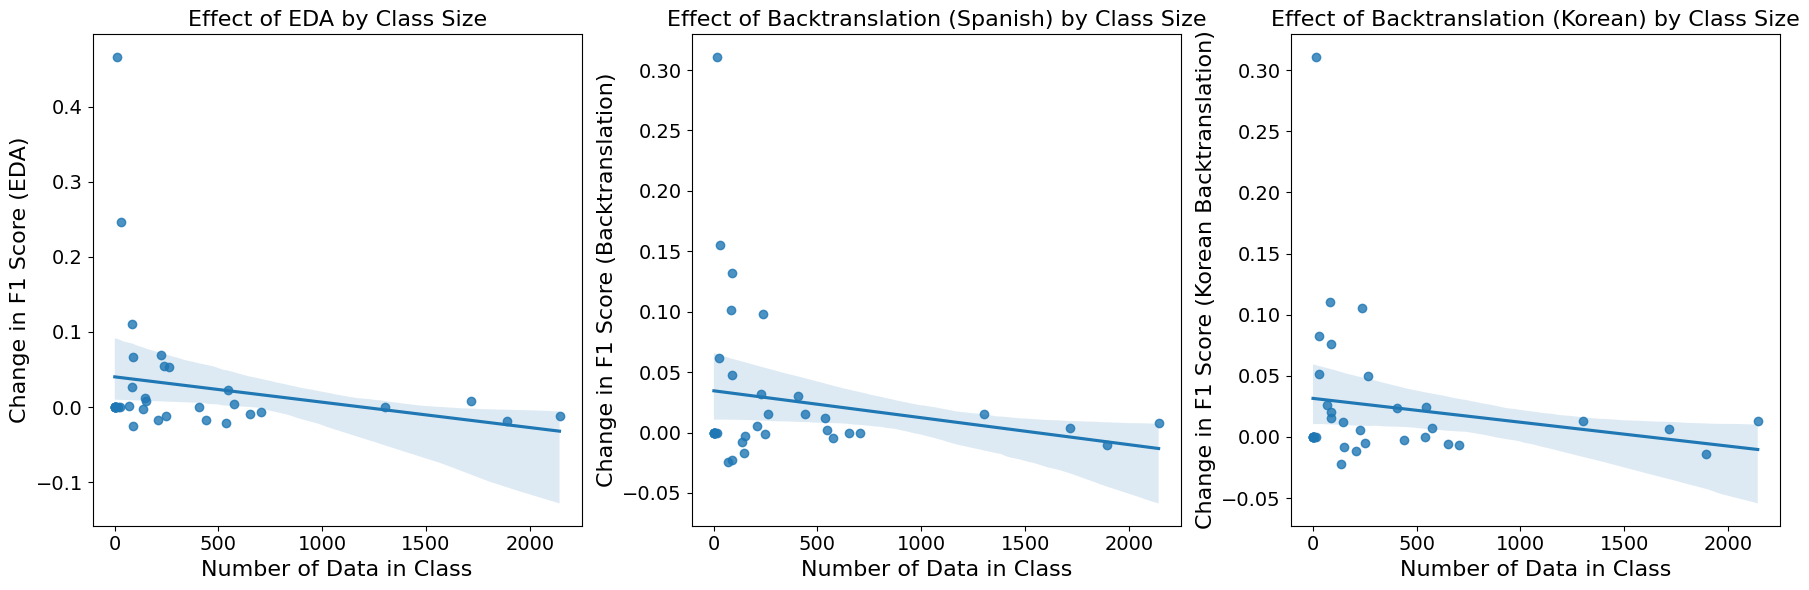

In [ ]:
# Visualization
plt.figure(figsize=(18, 6))

# Font sizes
title_fontsize = 16
label_fontsize = 16
tick_fontsize = 14

# EDA increment vs count_train_original
plt.subplot(1, 3, 1)
sns.regplot(x='count_train_original', y='f1_eda_increment', data=merged_df)
plt.title('Effect of EDA by Class Size', fontsize=title_fontsize)
plt.xlabel('Number of Data in Class', fontsize=label_fontsize)
plt.ylabel('Change in F1 Score (EDA)', fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# BT increment vs count_train_original
plt.subplot(1, 3, 2)
sns.regplot(x='count_train_original', y='f1_bt_increment', data=merged_df)
plt.title('Effect of Backtranslation (Spanish) by Class Size', fontsize=title_fontsize)
plt.xlabel('Number of Data in Class', fontsize=label_fontsize)
plt.ylabel('Change in F1 Score (Backtranslation)', fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# BT KO increment vs count_train_original
plt.subplot(1, 3, 3)
sns.regplot(x='count_train_original', y='f1_bt_ko_increment', data=merged_df)
plt.title('Effect of Backtranslation (Korean) by Class Size', fontsize=title_fontsize)
plt.xlabel('Number of Data in Class', fontsize=label_fontsize)
plt.ylabel('Change in F1 Score (Korean Backtranslation)', fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

plt.tight_layout()
plt.show()


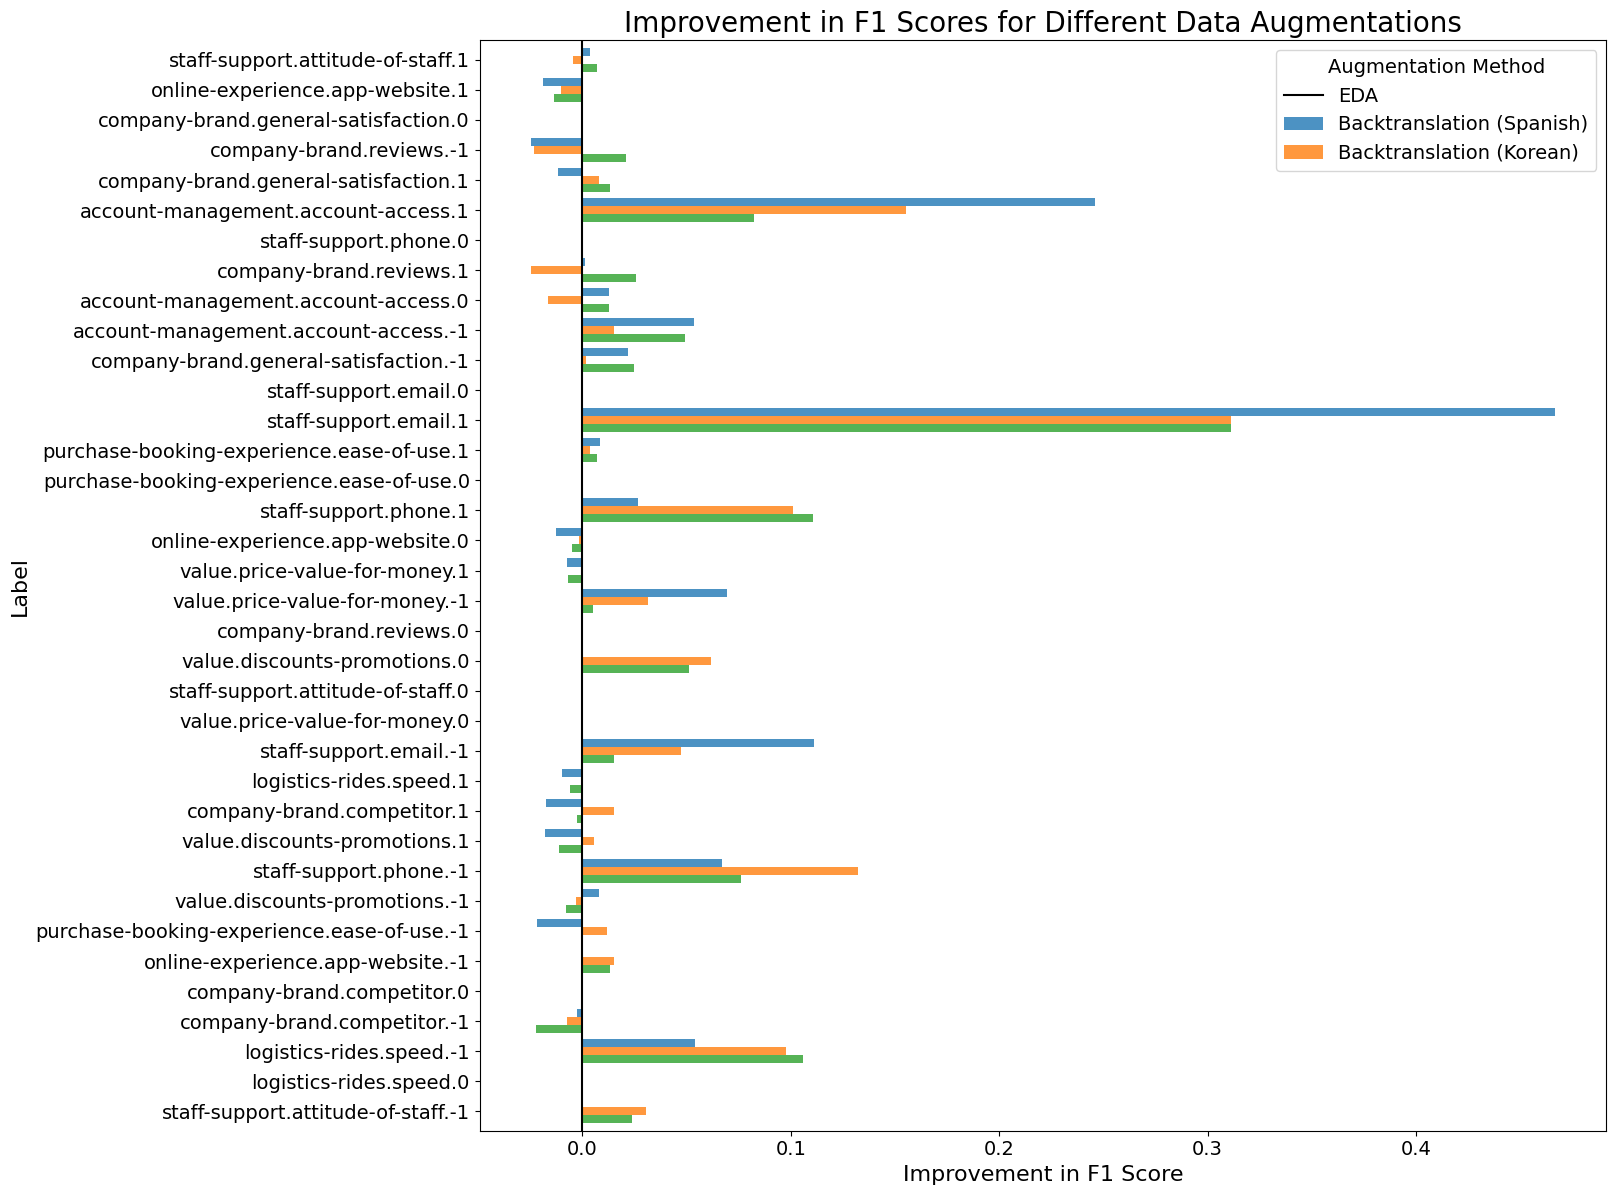

In [ ]:

def plot_improvements(data):
    """Visualize the F1 score improvements for different augmentations."""

    # Font sizes
    title_fontsize = 20
    label_fontsize = 16
    tick_fontsize = 14
    legend_fontsize = 14

    # Plotting
    ax = data.set_index('label')[['f1_eda_increment', 'f1_bt_increment', 'f1_bt_ko_increment']].plot(
        kind='barh', figsize=(15, 12), width=0.8, alpha=0.8  # Increased bar width slightly
    )

    plt.axvline(0, color='black', linewidth=1.5)  # Emphasized horizontal line at x=0
    plt.title('Improvement in F1 Scores for Different Data Augmentations', fontsize=title_fontsize)
    plt.xlabel('Improvement in F1 Score', fontsize=label_fontsize)
    plt.ylabel('Label', fontsize=label_fontsize)
    plt.tight_layout()

    # Renaming the legend
    ax.legend(
        ['EDA', 'Backtranslation (Spanish)', 'Backtranslation (Korean)'],
        title='Augmentation Method', fontsize=legend_fontsize, title_fontsize=legend_fontsize
    )
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.tick_params(axis='x', labelsize=tick_fontsize)
    plt.gca().invert_yaxis()  # to have the first class at the top
    plt.show()

plot_improvements(merged_df)


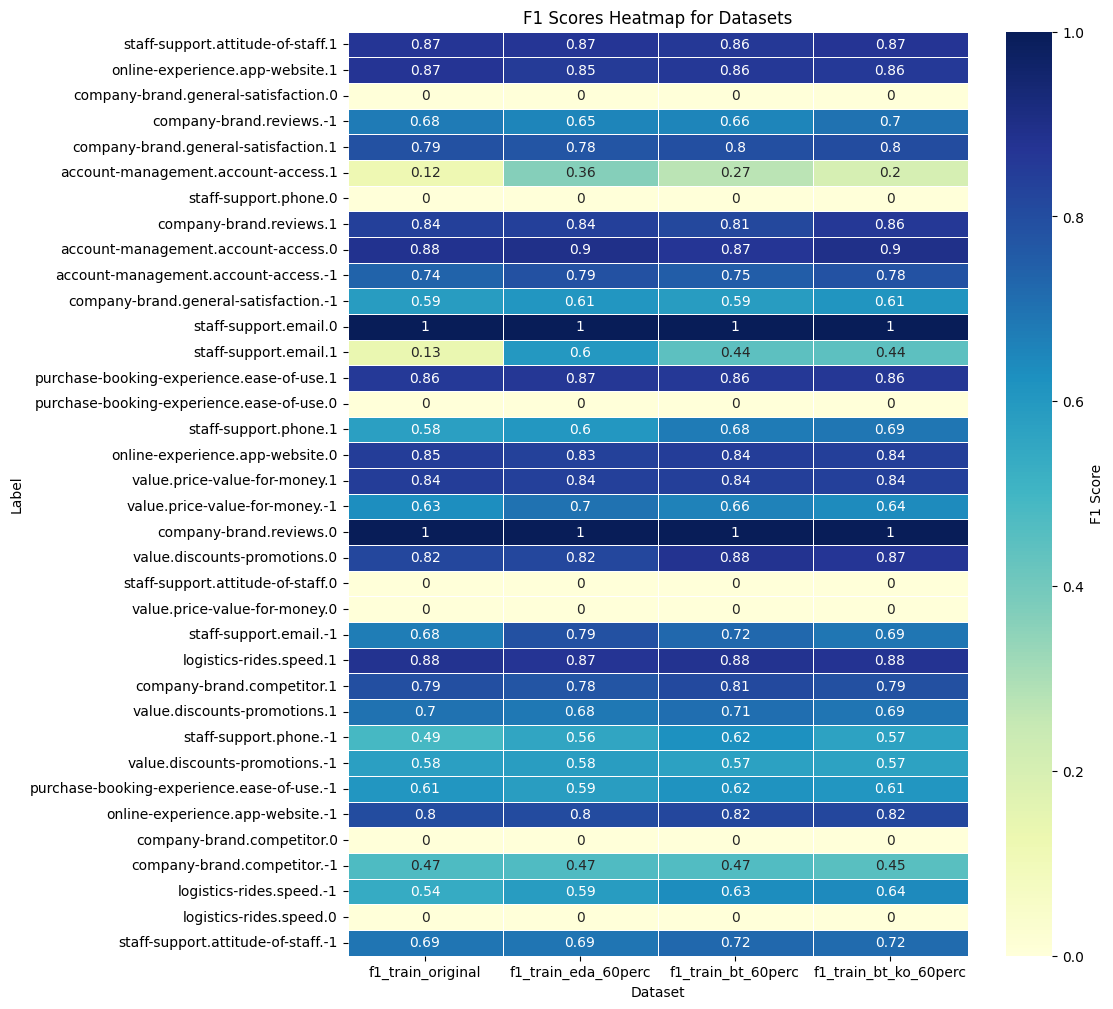

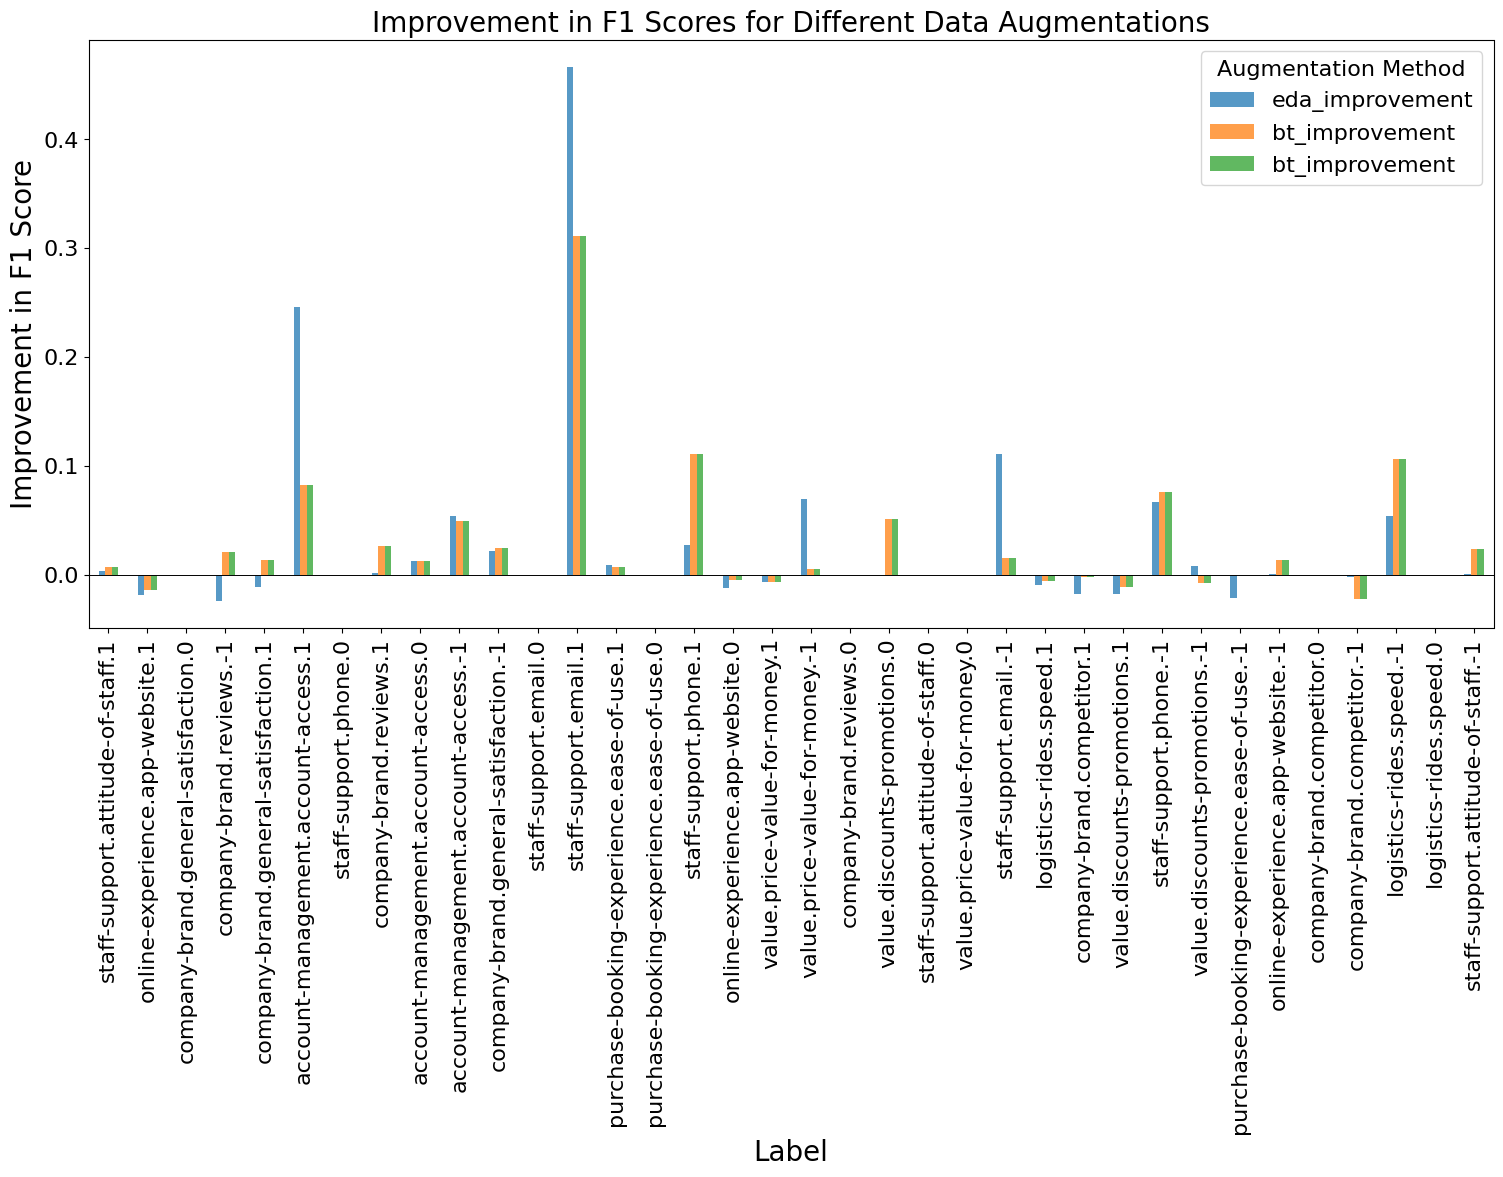

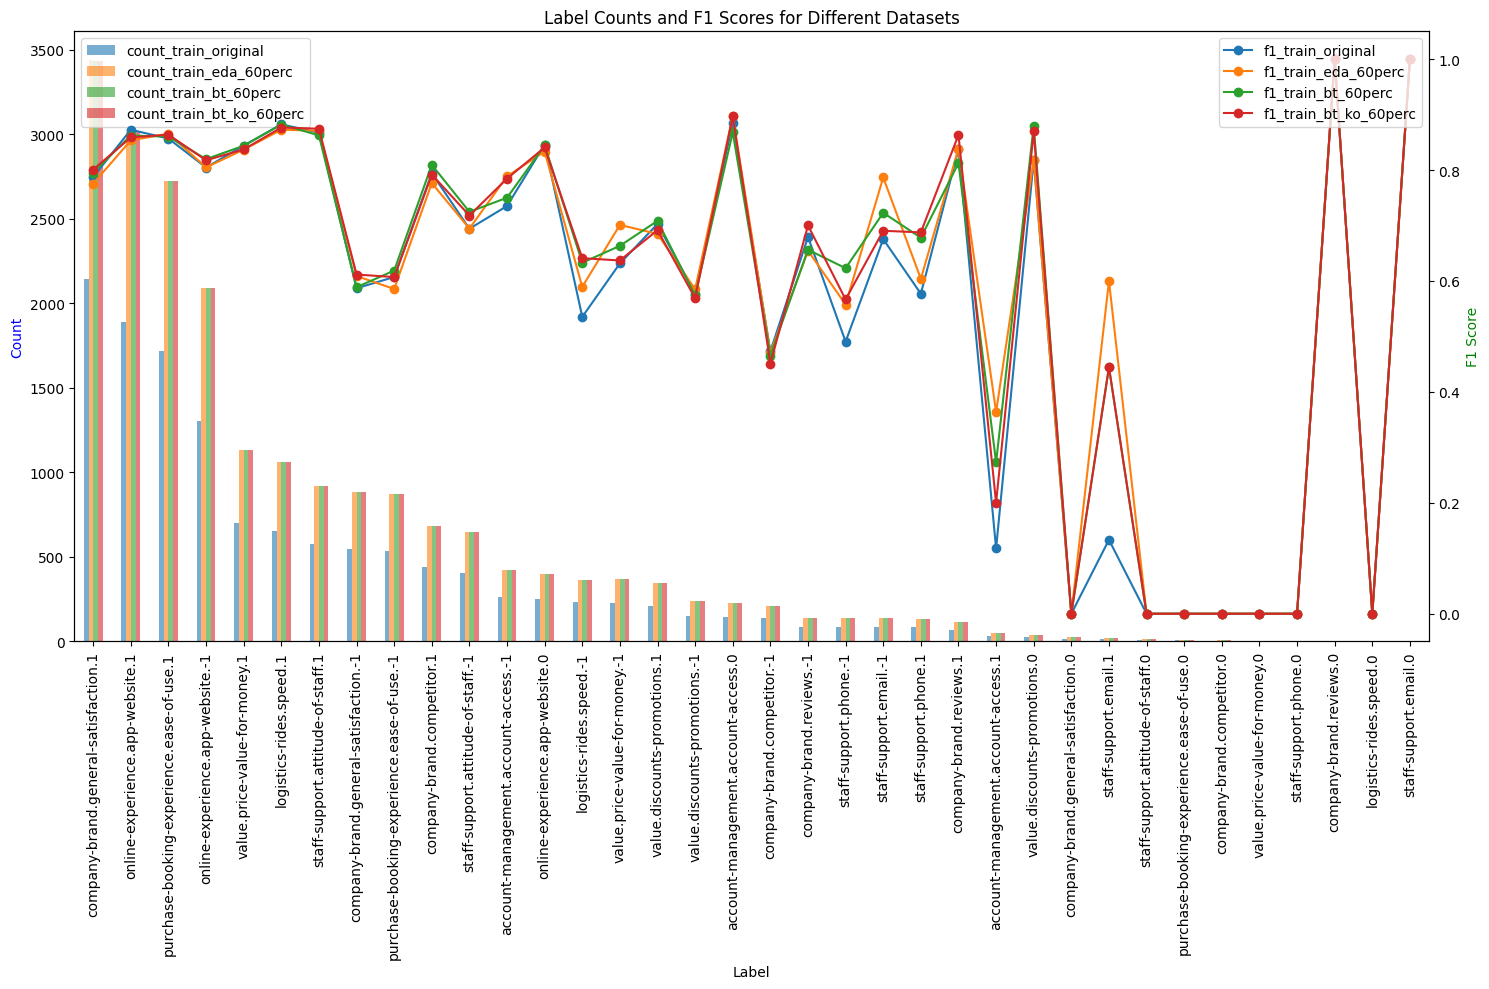

In [ ]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns
dataset_files = {
        'train_original': "/content/gdrive/My Drive/MSc Project/train_df.csv",
        'train_eda_60perc': "/content/gdrive/My Drive/MSc Project/train_eda_60.0.csv",
        'train_bt_60perc': "/content/gdrive/My Drive/MSc Project/backtrans_60.csv",
        'train_bt_ko_60perc': "/content/gdrive/My Drive/MSc Project/backtrans_ko_60.csv"
    }
datasets_list = ["train_original", "train_eda_60perc", "train_bt_60perc", "train_bt_ko_60perc"]
model_name = "bertbase"  # or whatever model name you're using
main(datasets_list, model_name, dataset_files)

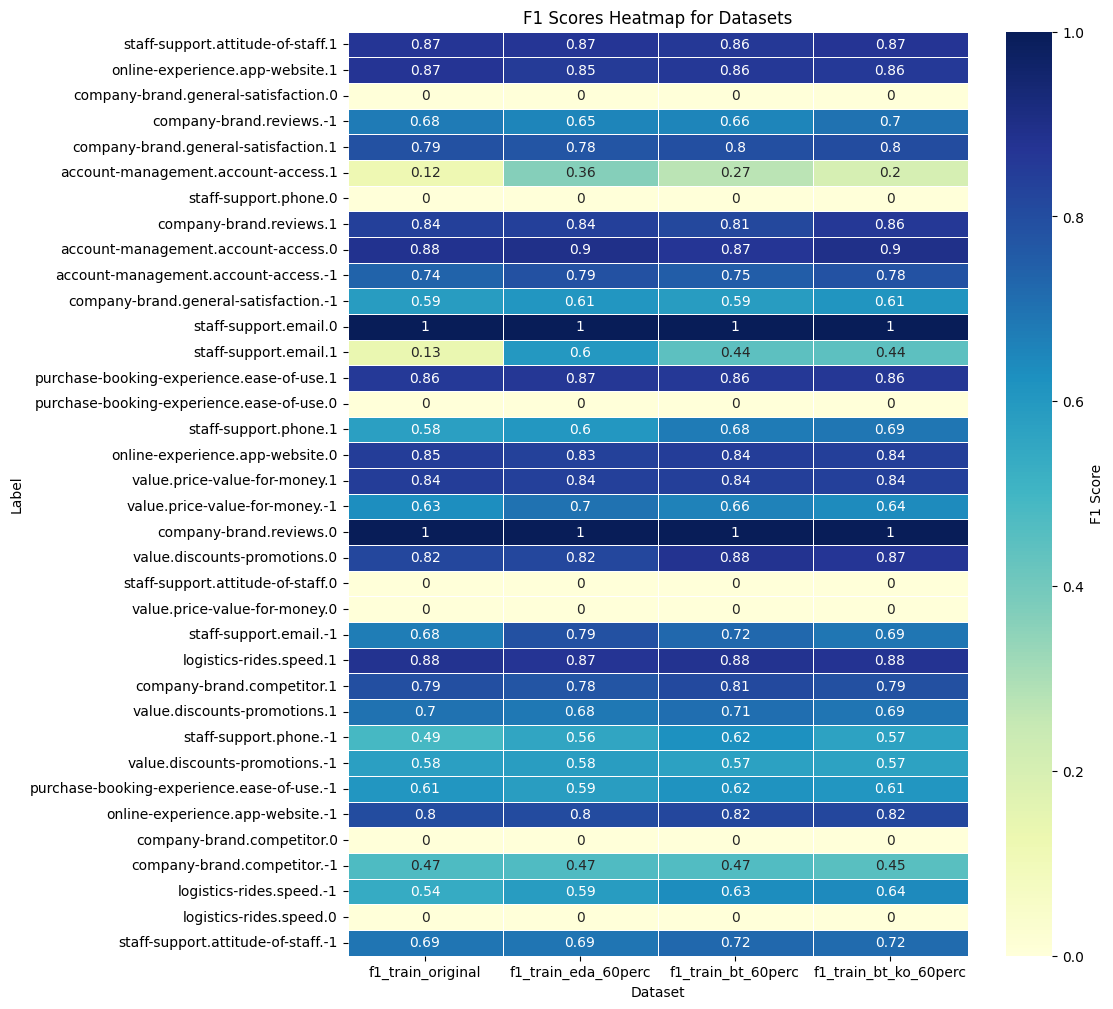

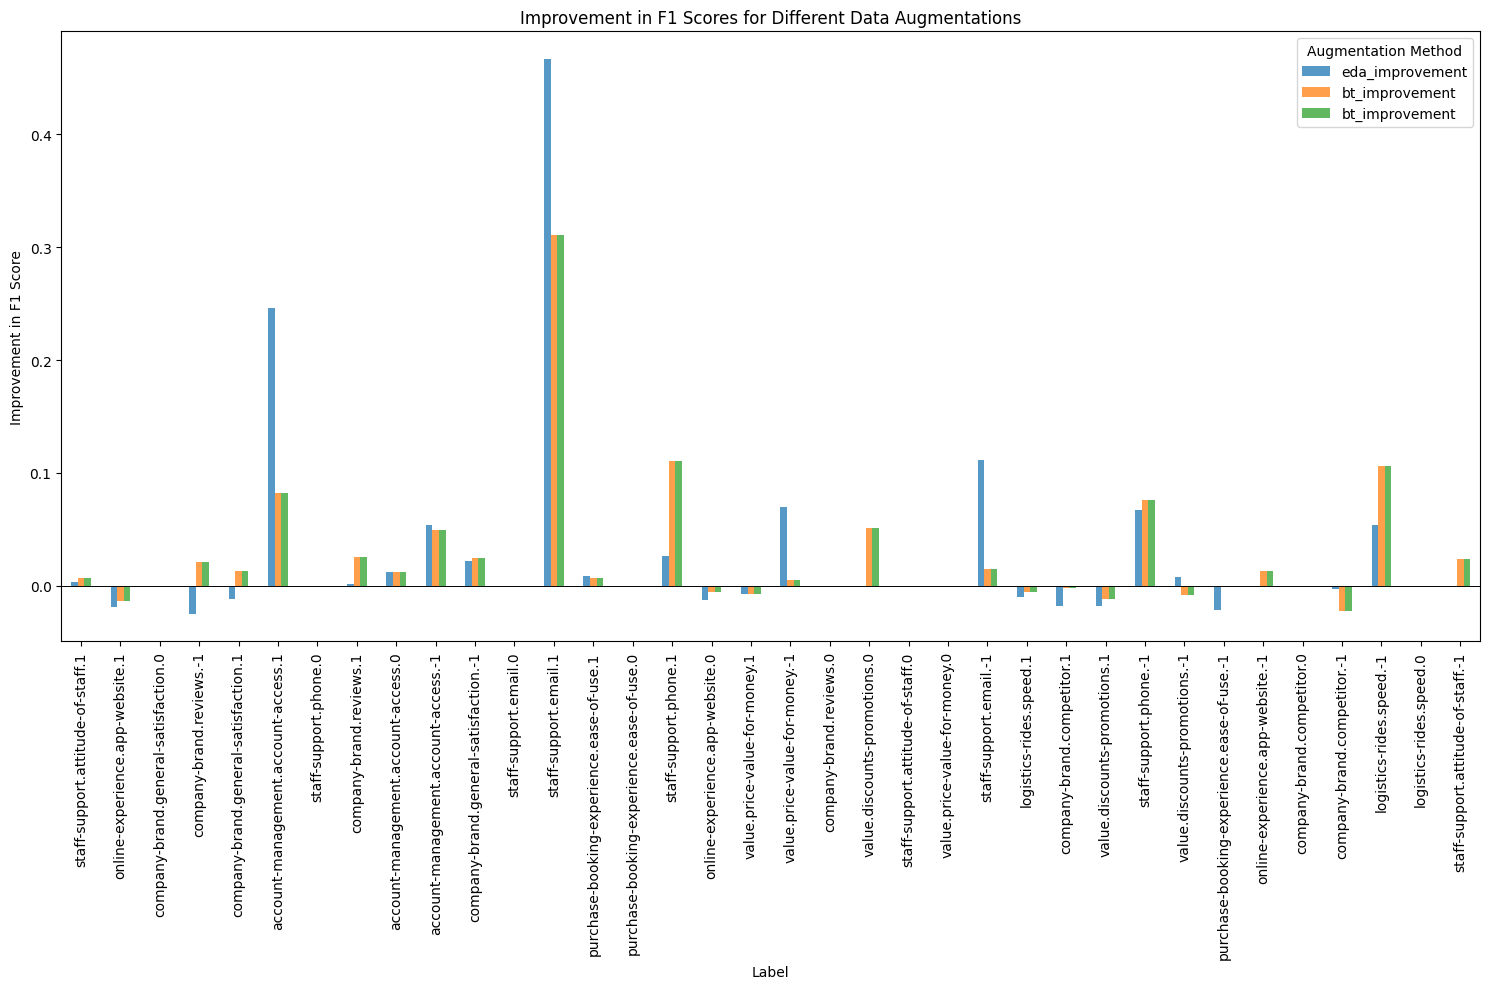

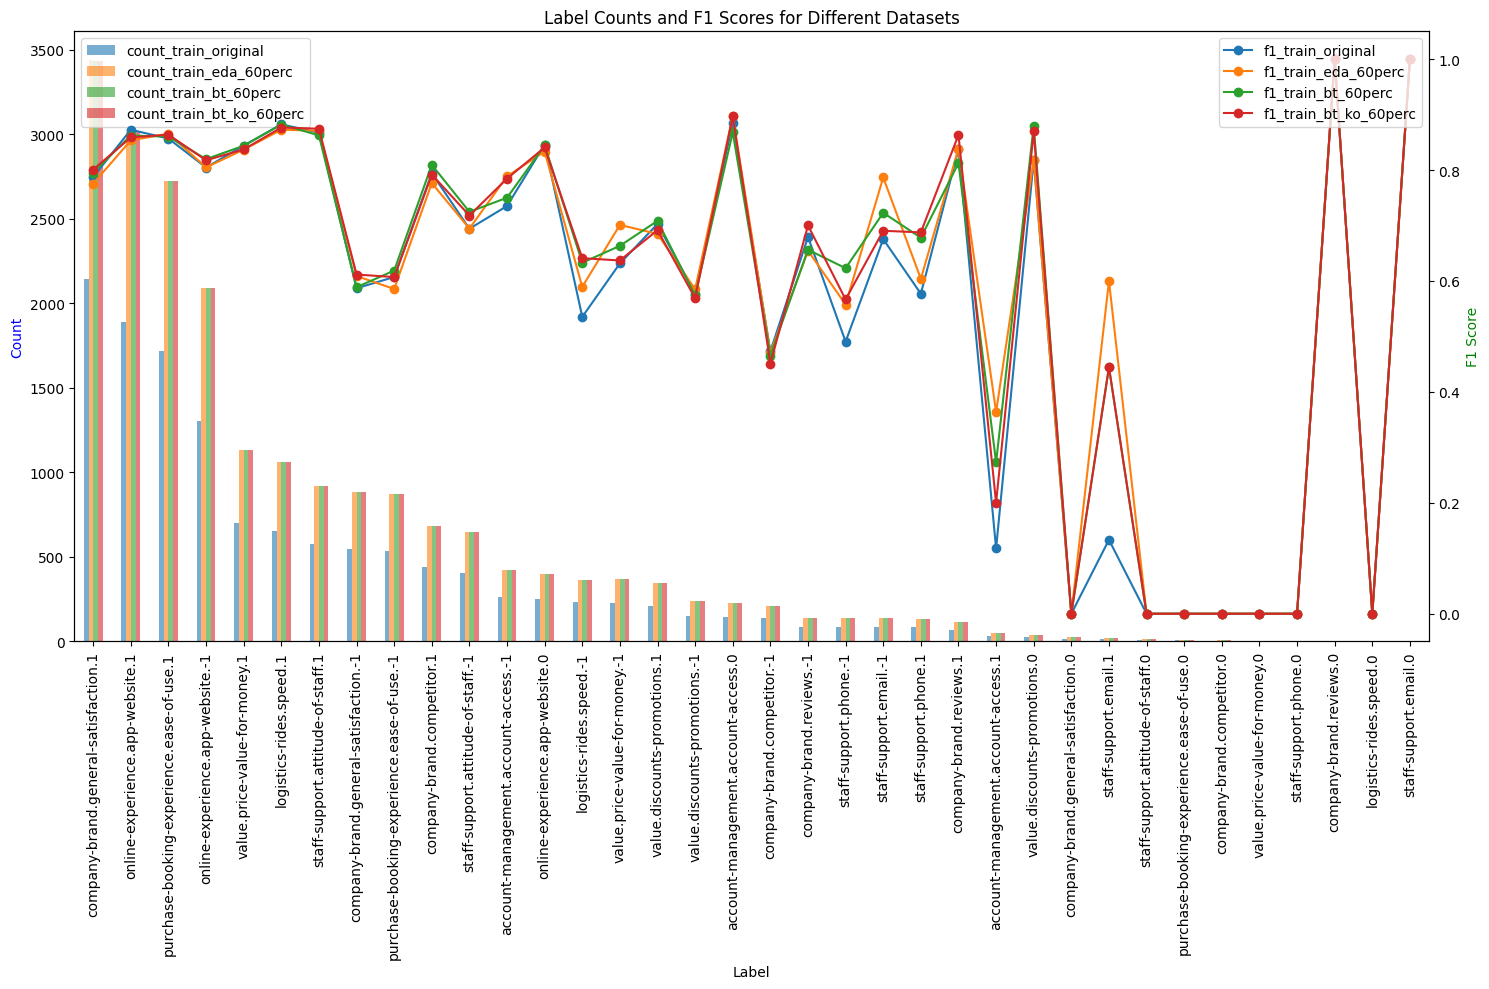

In [ ]:
dataset_files = {
        'train_original': "/content/gdrive/My Drive/MSc Project/train_df.csv",
        'train_eda_60perc': "/content/gdrive/My Drive/MSc Project/train_eda_60.0.csv",
        'train_bt_60perc': "/content/gdrive/My Drive/MSc Project/backtrans_60.csv",
        'train_bt_ko_60perc': "/content/gdrive/My Drive/MSc Project/backtrans_ko_60.csv"
    }
datasets_list = ["train_original", "train_eda_60perc", "train_bt_60perc", "train_bt_ko_60perc"]
model_name = "bertbase"  # or whatever model name you're using
main(datasets_list, model_name, dataset_files)

## 1%

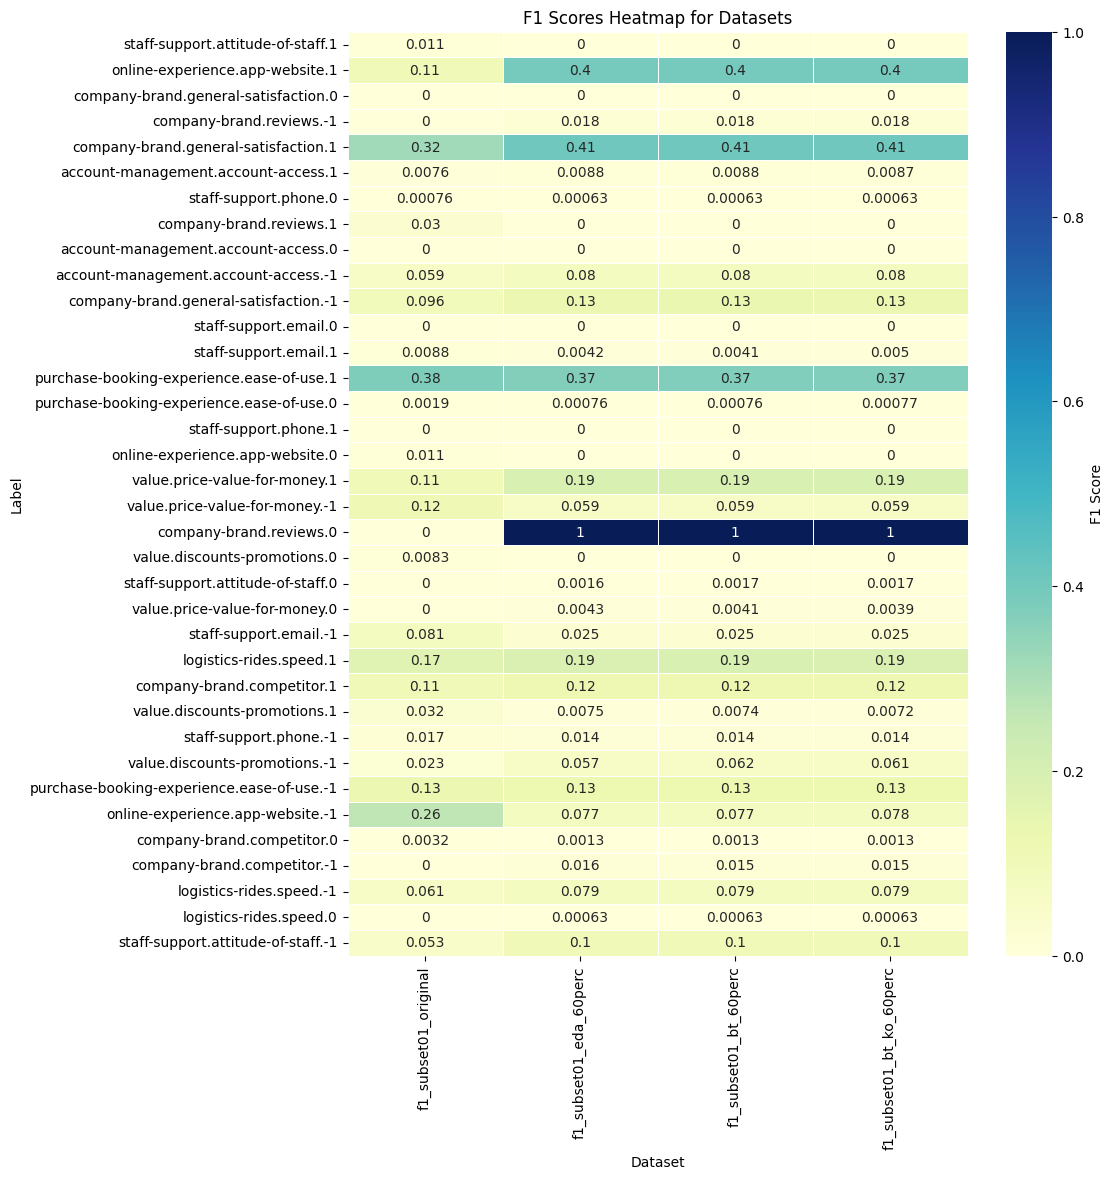

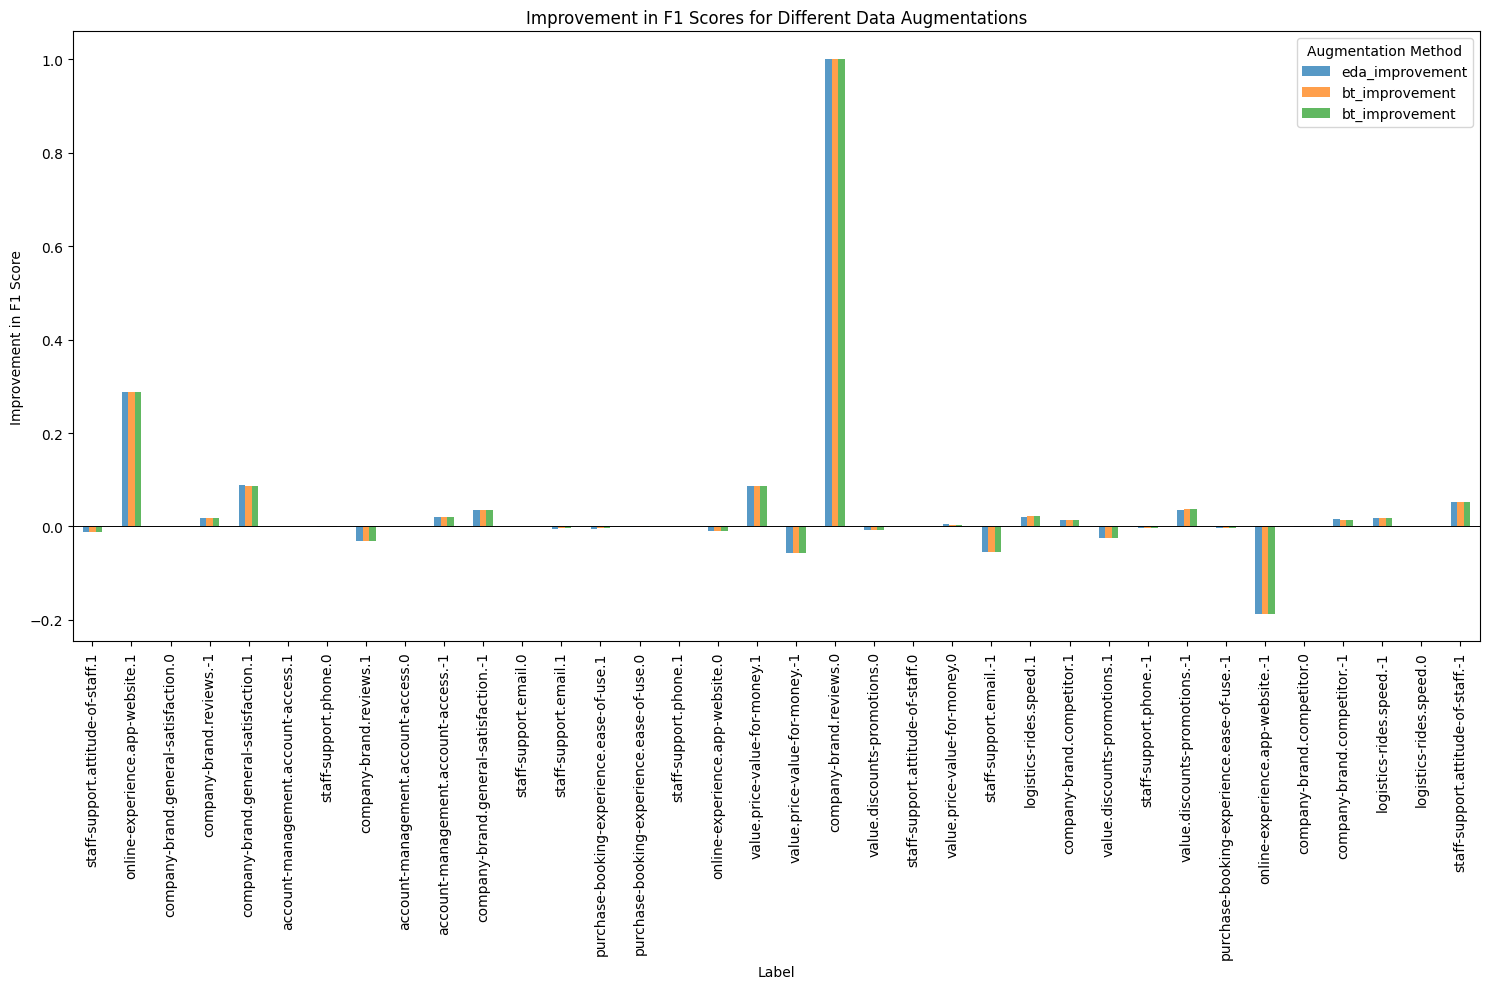

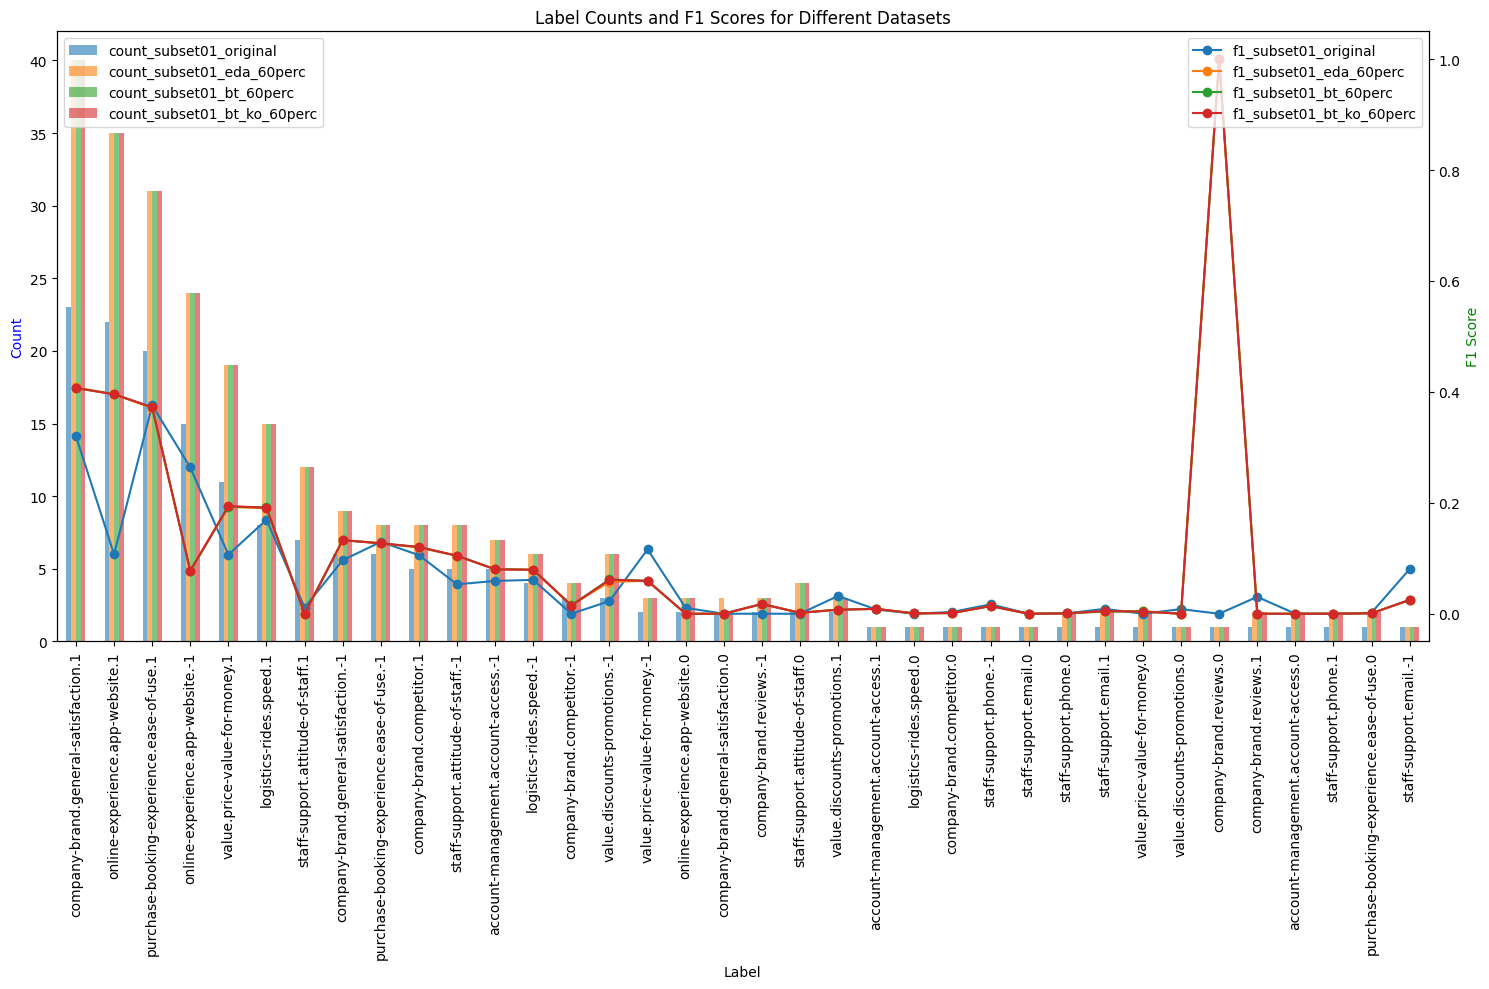

In [ ]:
dataset_files = {
        'subset01_original': "/content/gdrive/My Drive/MSc Project/train_subset.csv",
        'subset01_eda_60perc': "/content/gdrive/My Drive/MSc Project/subset_eda_60.0.csv",
        'subset01_bt_60perc': "/content/gdrive/My Drive/MSc Project/subset_backtrans_60.csv",
        'subset01_bt_ko_60perc': "/content/gdrive/My Drive/MSc Project/subset_backtrans_ko60.csv"
    }
datasets_list = ["subset01_original", "subset01_eda_60perc", "subset01_bt_60perc", "subset01_bt_ko_60perc"]
model_name = "bertbase"  # or whatever model name you're using
main(datasets_list, model_name, dataset_files)

## 5%

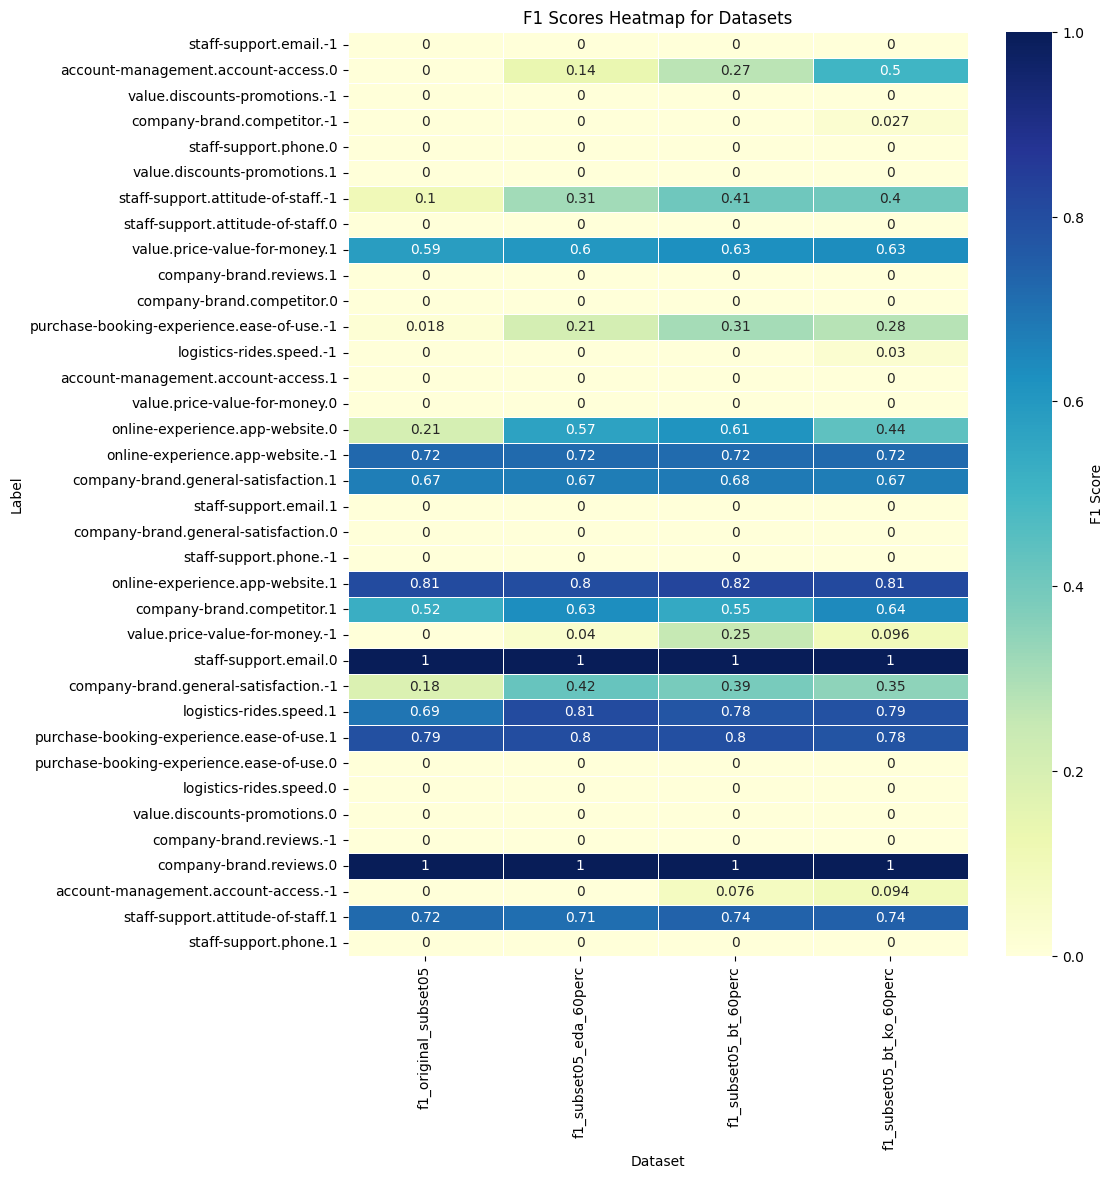

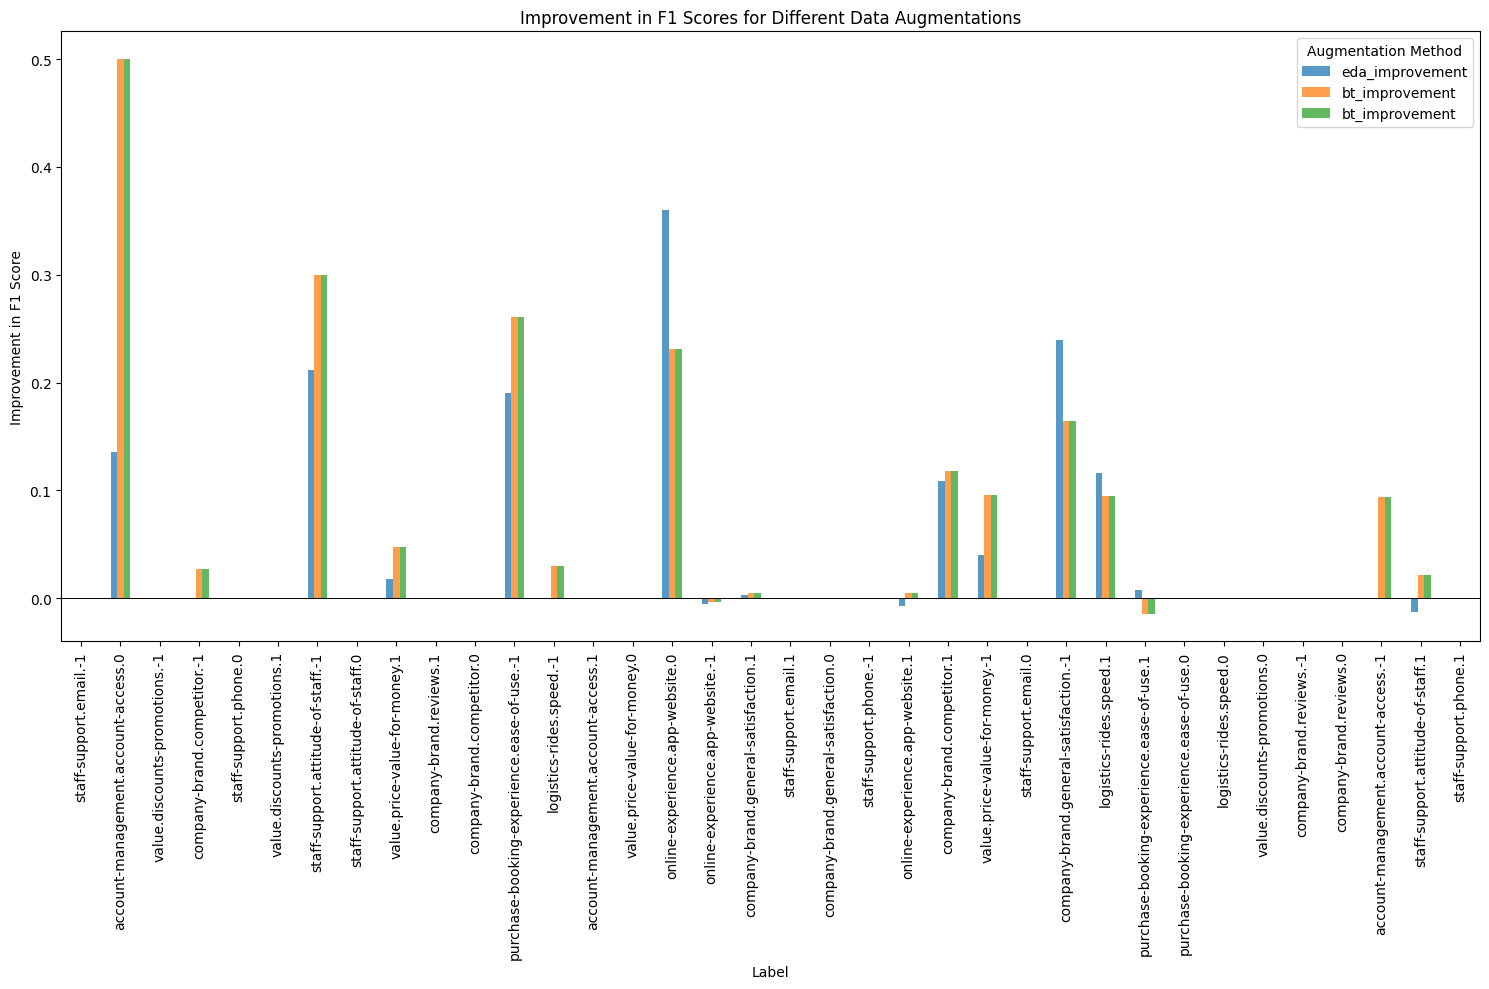

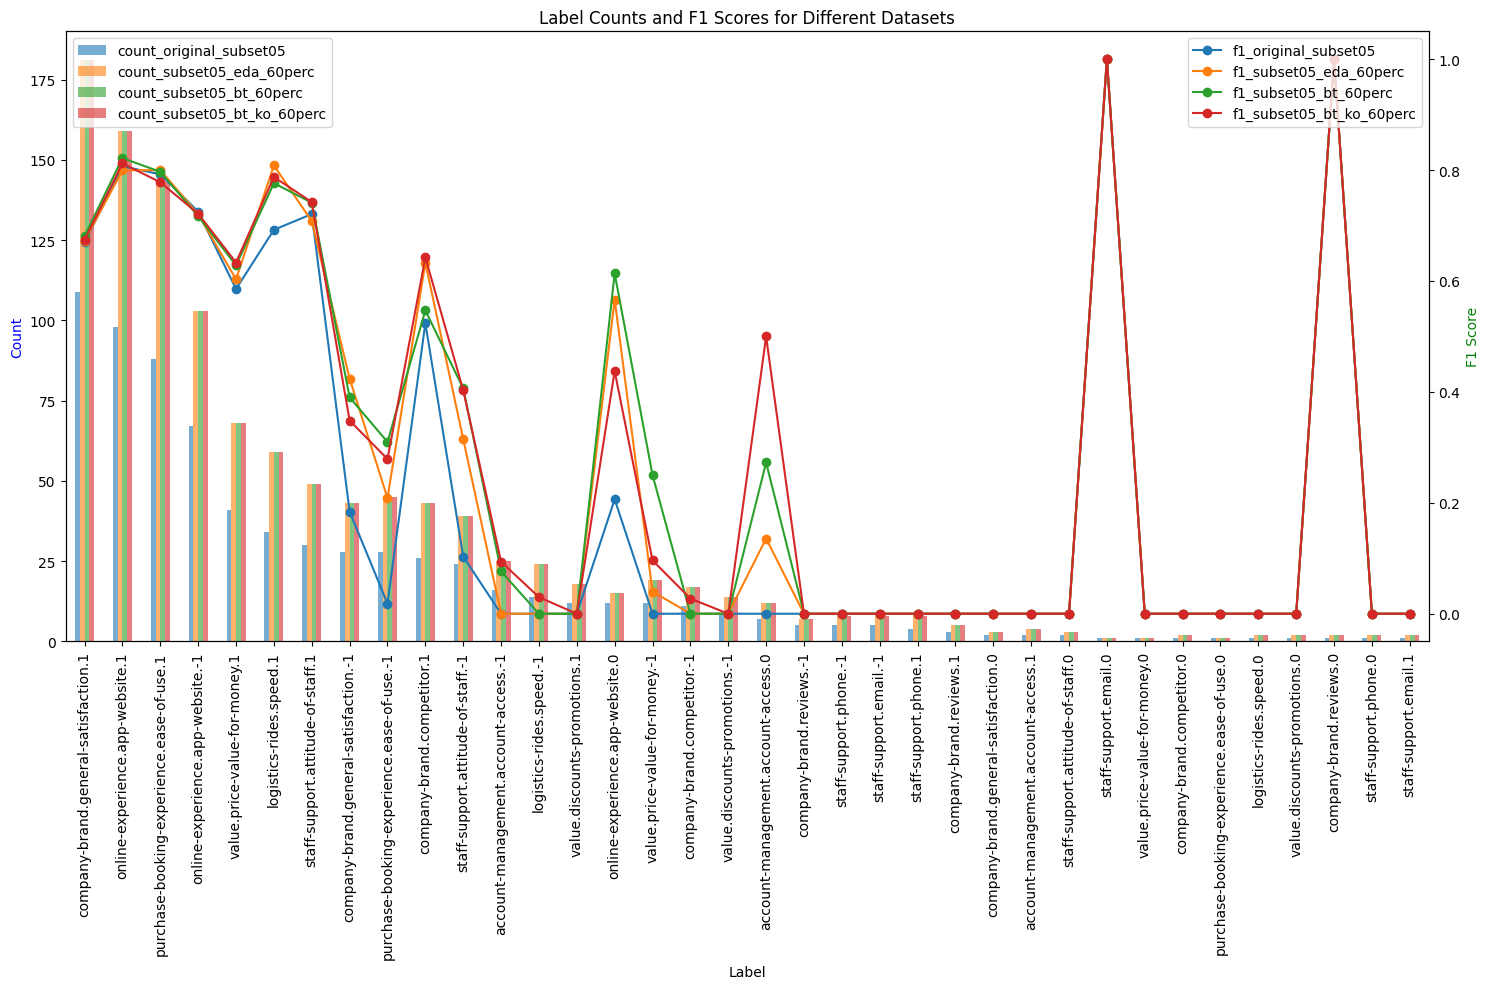

In [ ]:
dataset_files = {
        'original_subset05': "/content/gdrive/My Drive/MSc Project/train_subset5.csv",
        'subset05_eda_60perc': "/content/gdrive/My Drive/MSc Project/subset5_eda_60.0.csv",
        'subset05_bt_60perc': "/content/gdrive/My Drive/MSc Project/subset5_backtrans_60.csv",
        'subset05_bt_ko_60perc': "/content/gdrive/My Drive/MSc Project/subset05_backtrans_ko60.csv"
    }
datasets_list = ["original_subset05", "subset05_eda_60perc", "subset05_bt_60perc", "subset05_bt_ko_60perc"]
model_name = "bertbase"  # or whatever model name you're using
main(datasets_list, model_name, dataset_files)

##10%

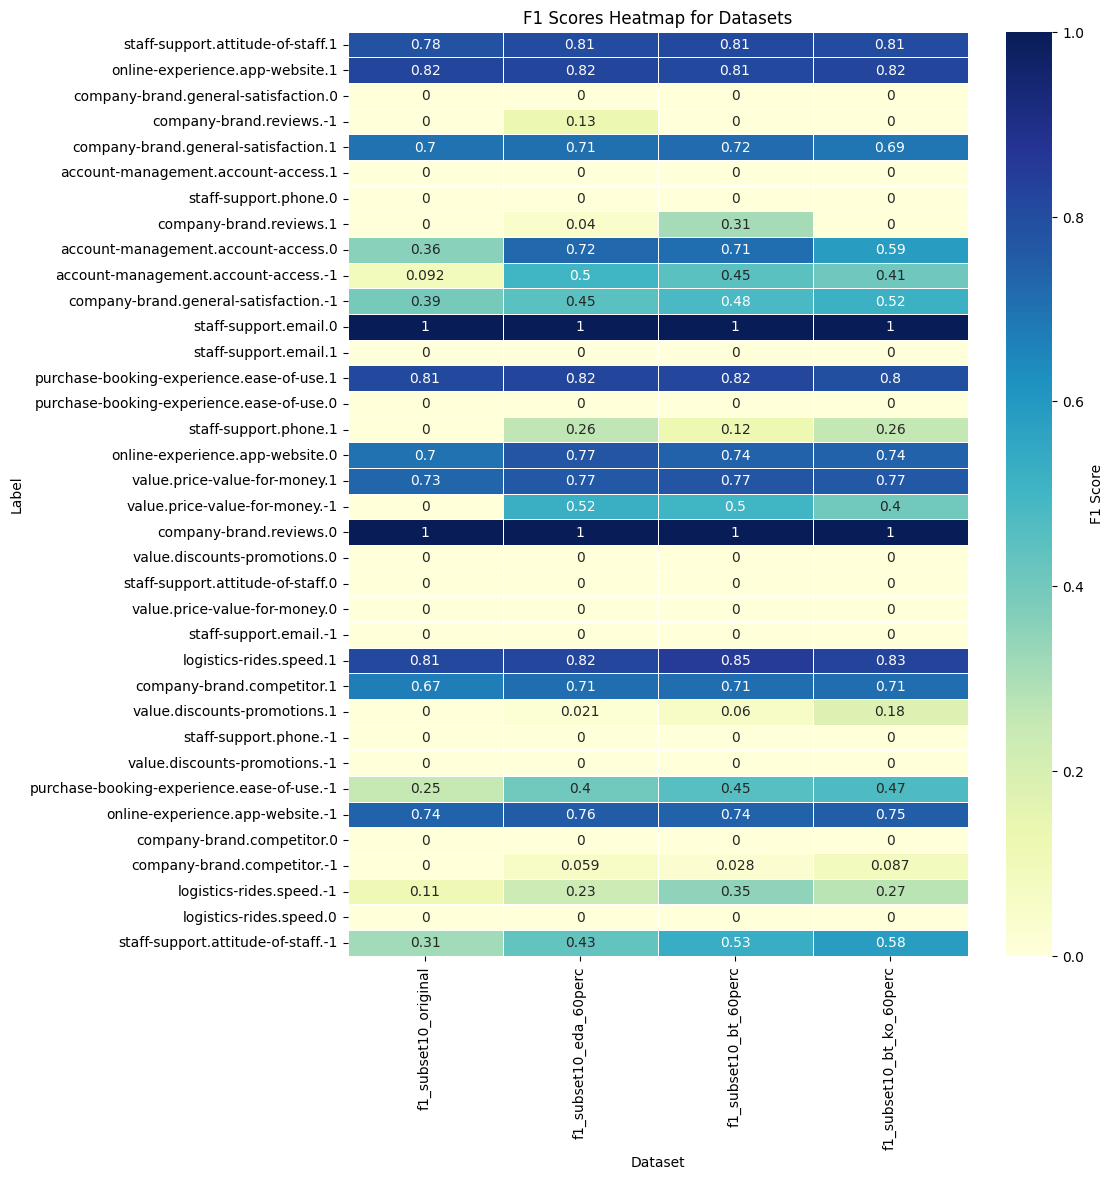

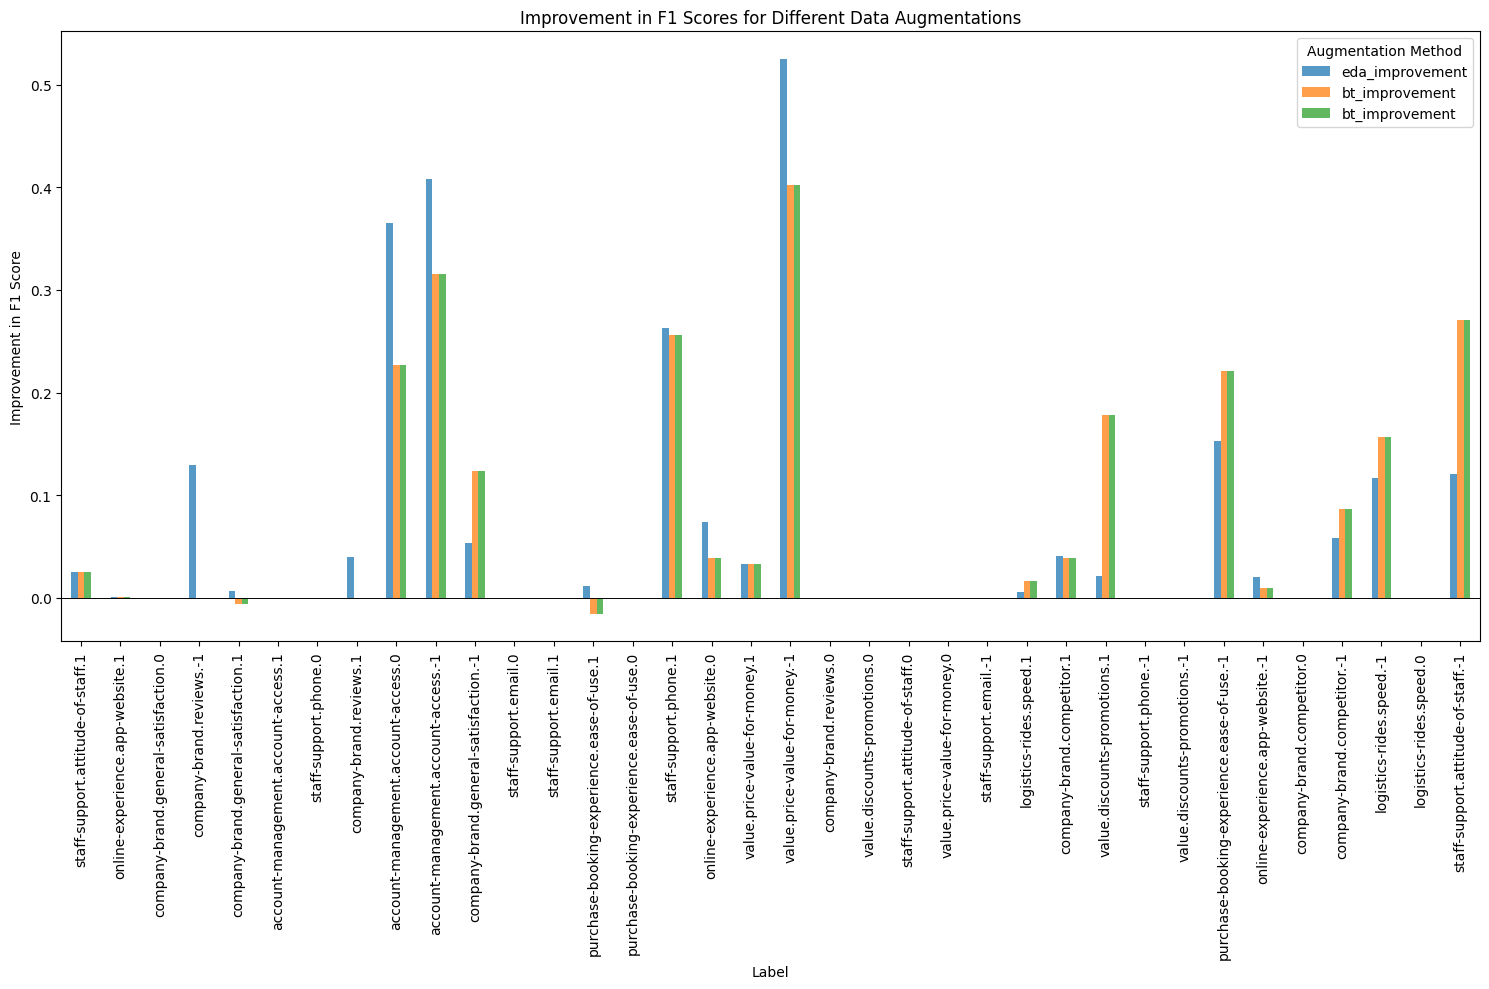

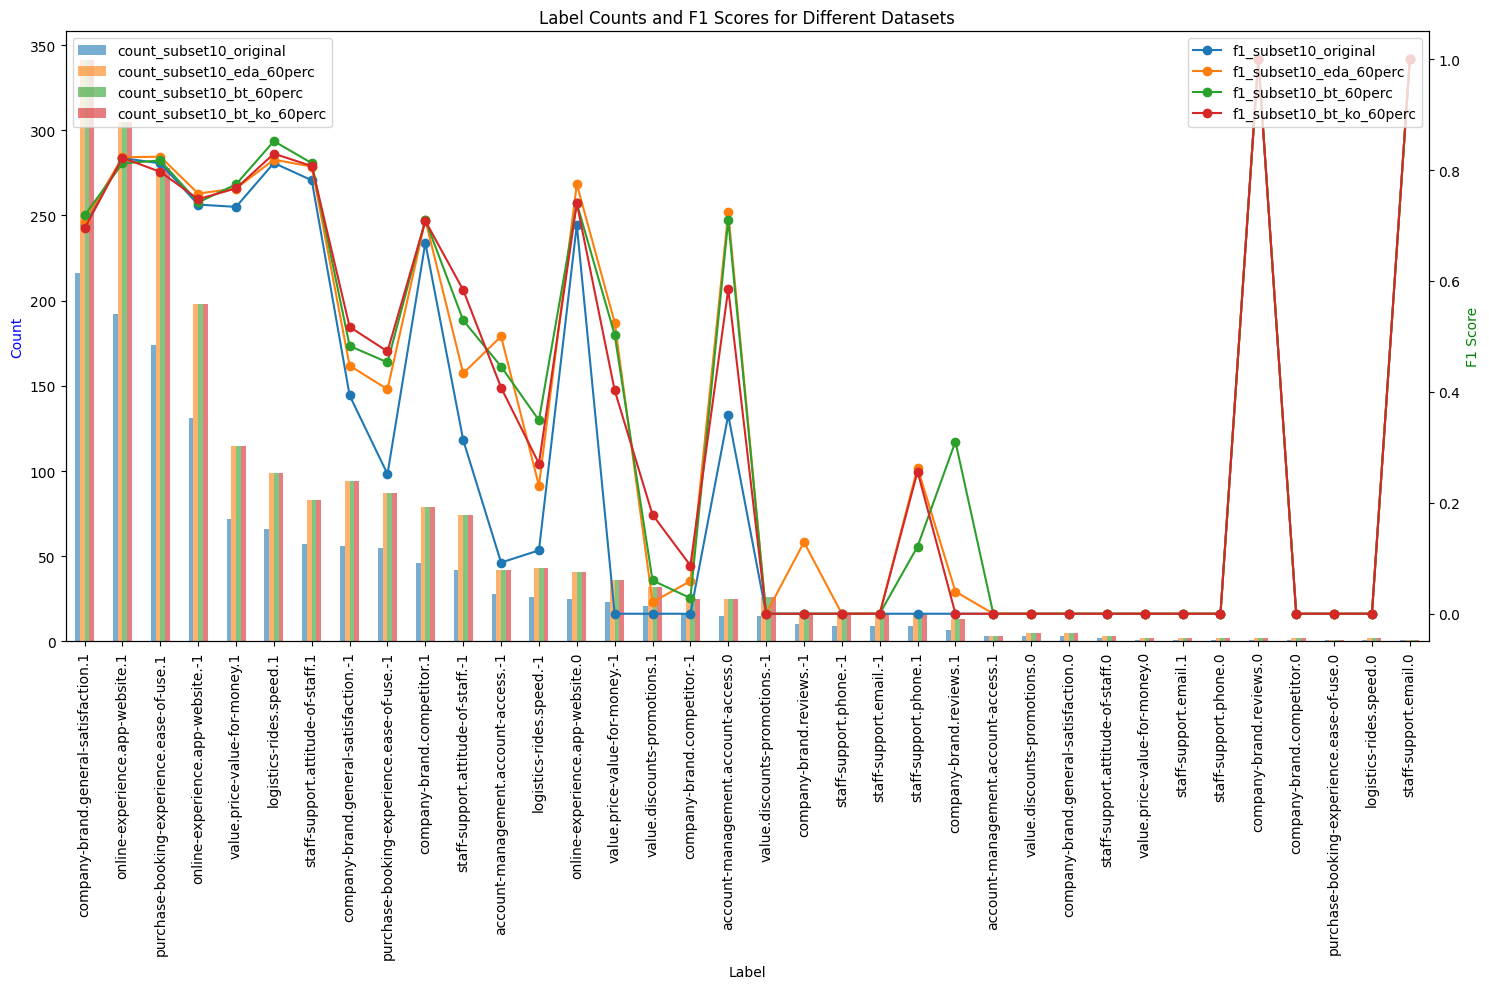

In [ ]:
dataset_files = {
        'subset10_original': "/content/gdrive/My Drive/MSc Project/train_subset10.csv",
        'subset10_eda_60perc': "/content/gdrive/My Drive/MSc Project/subset10_eda_60.0.csv",
        'subset10_bt_60perc': "/content/gdrive/My Drive/MSc Project/subset10_backtrans_60.csv",
        'subset10_bt_ko_60perc': "/content/gdrive/My Drive/MSc Project/subset10_backtrans_ko60.csv"
    }
datasets_list = ["subset10_original", "subset10_eda_60perc", "subset10_bt_60perc", "subset10_bt_ko_60perc"]
model_name = "bertbase"  # or whatever model name you're using
main(datasets_list, model_name, dataset_files)

##20%

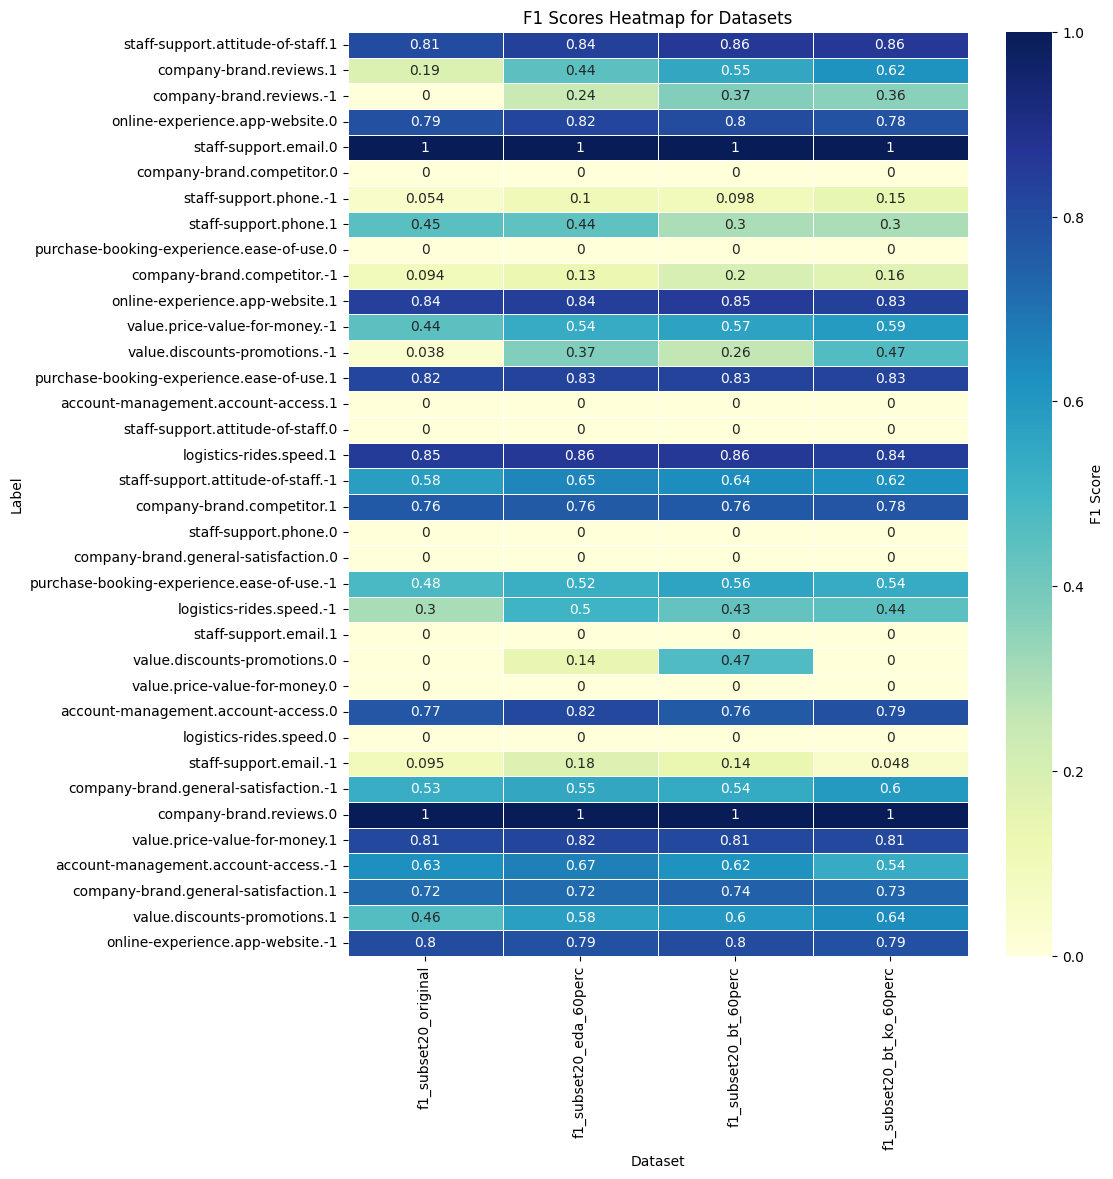

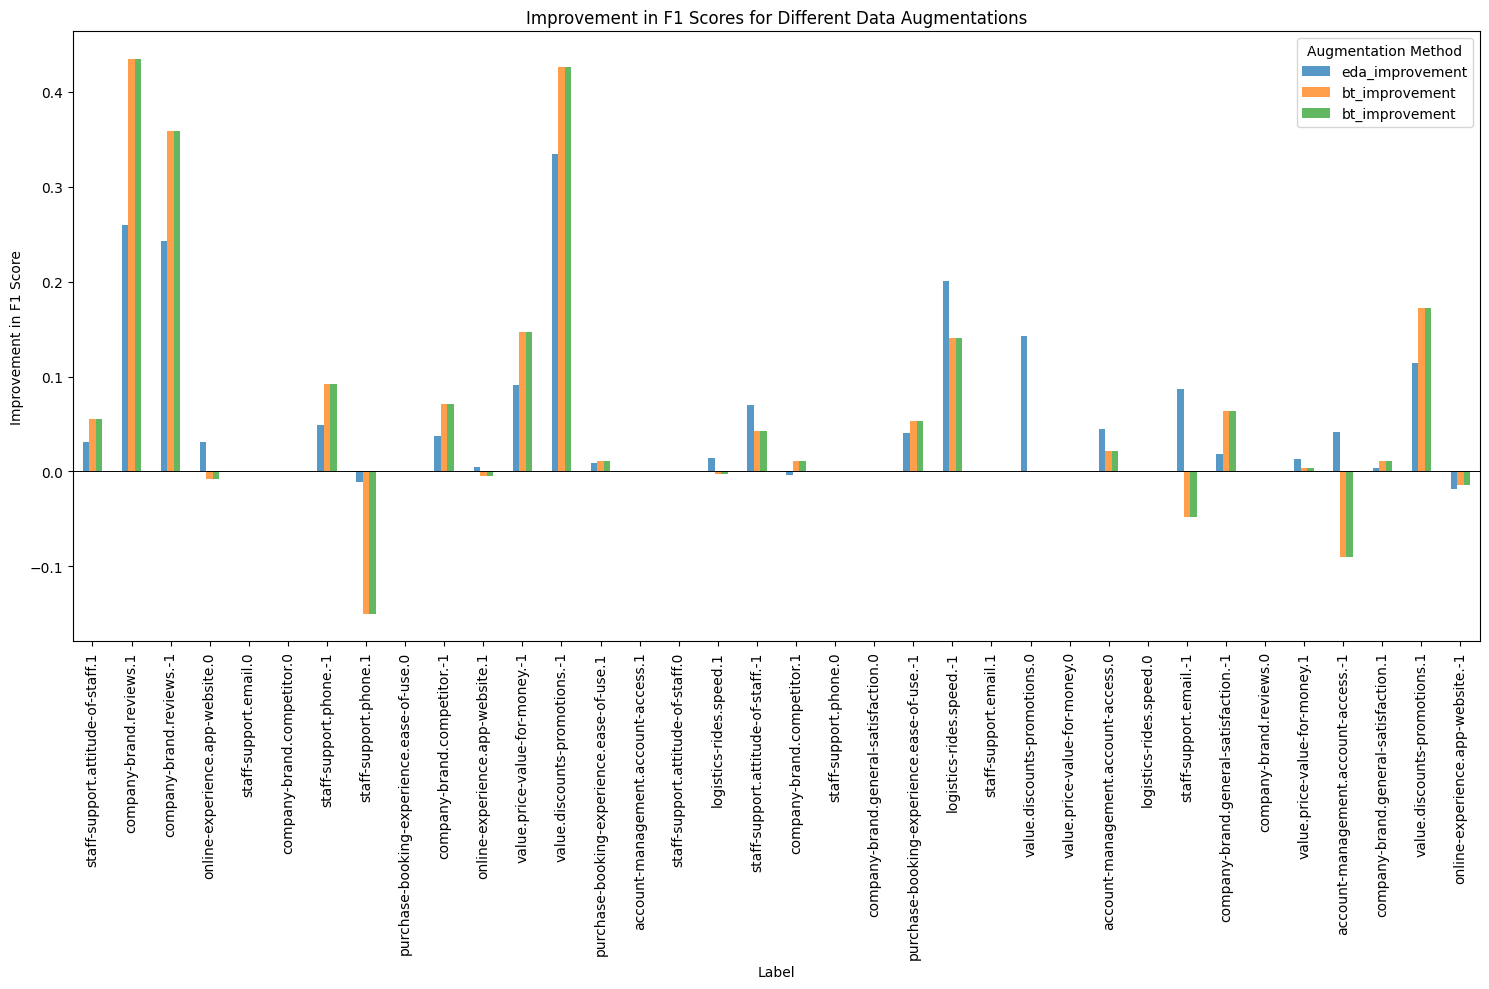

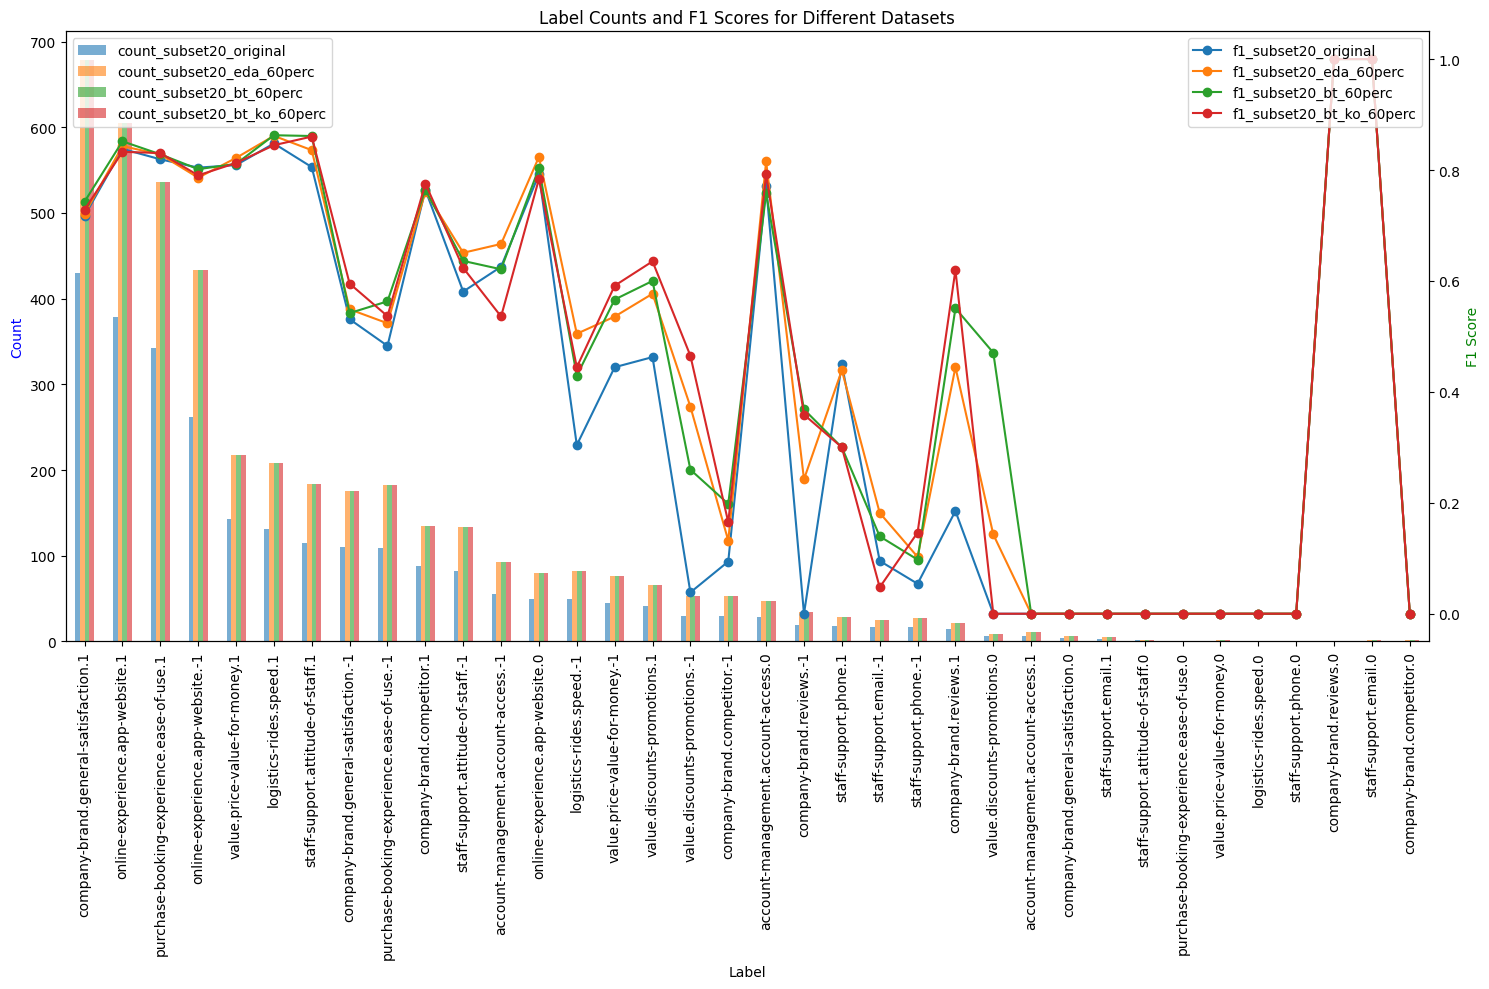

In [ ]:
dataset_files = {
        'subset20_original': "/content/gdrive/My Drive/MSc Project/train_subset20.csv",
        'subset20_eda_60perc': "/content/gdrive/My Drive/MSc Project/subset20_eda_60.0.csv",
        'subset20_bt_60perc': "/content/gdrive/My Drive/MSc Project/subset20_backtrans_60.csv",
        'subset20_bt_ko_60perc': "/content/gdrive/My Drive/MSc Project/subset20_backtrans_ko60.csv"
    }
datasets_list = ["subset20_original", "subset20_eda_60perc", "subset20_bt_60perc", "subset20_bt_ko_60perc"]
model_name = "bertbase"  # or whatever model name you're using
main(datasets_list, model_name, dataset_files)

## 30%

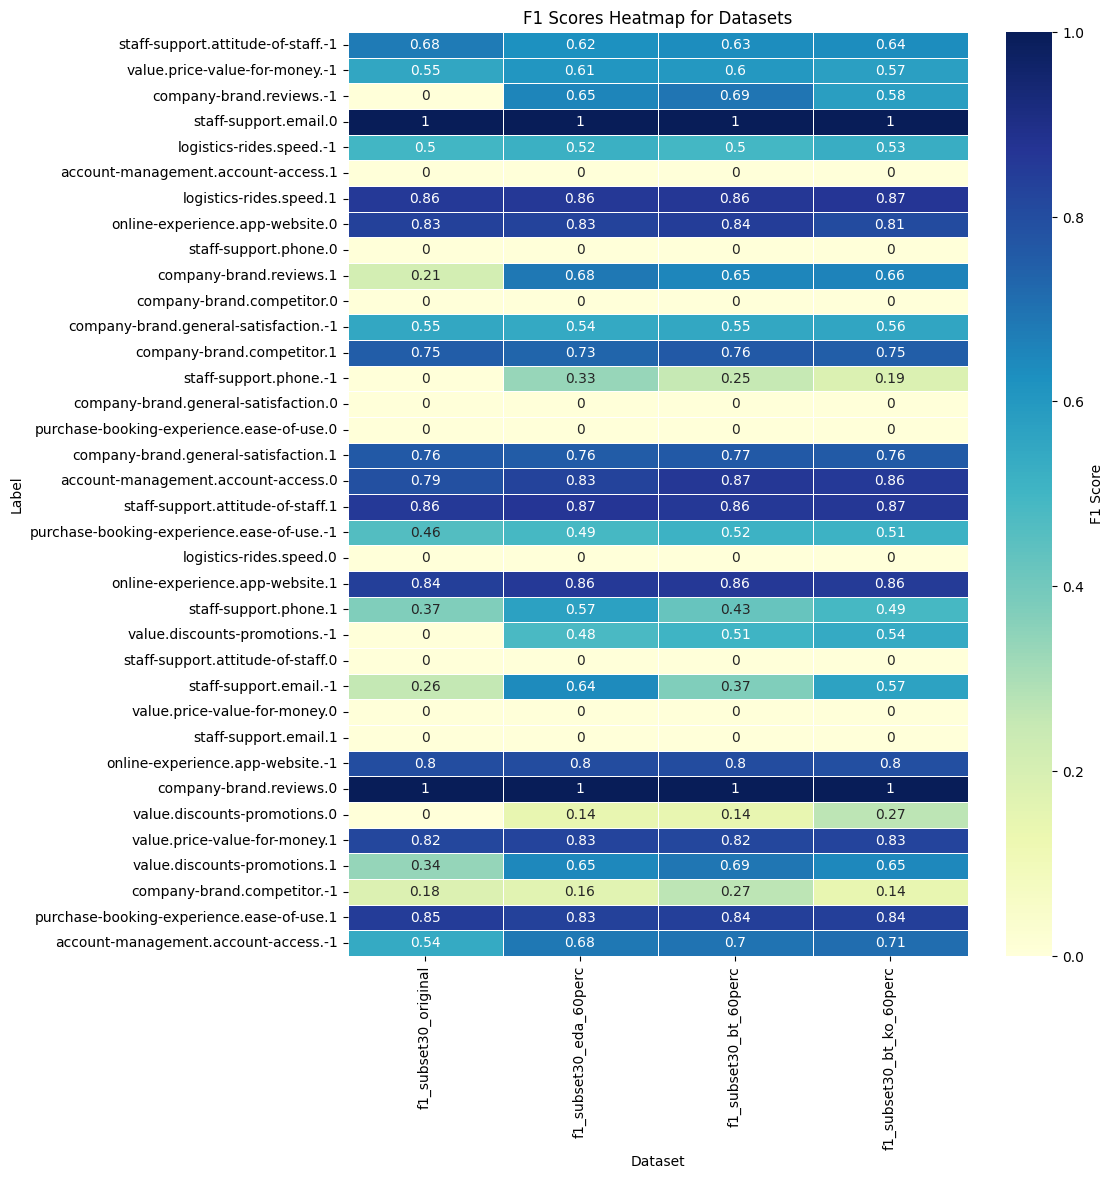

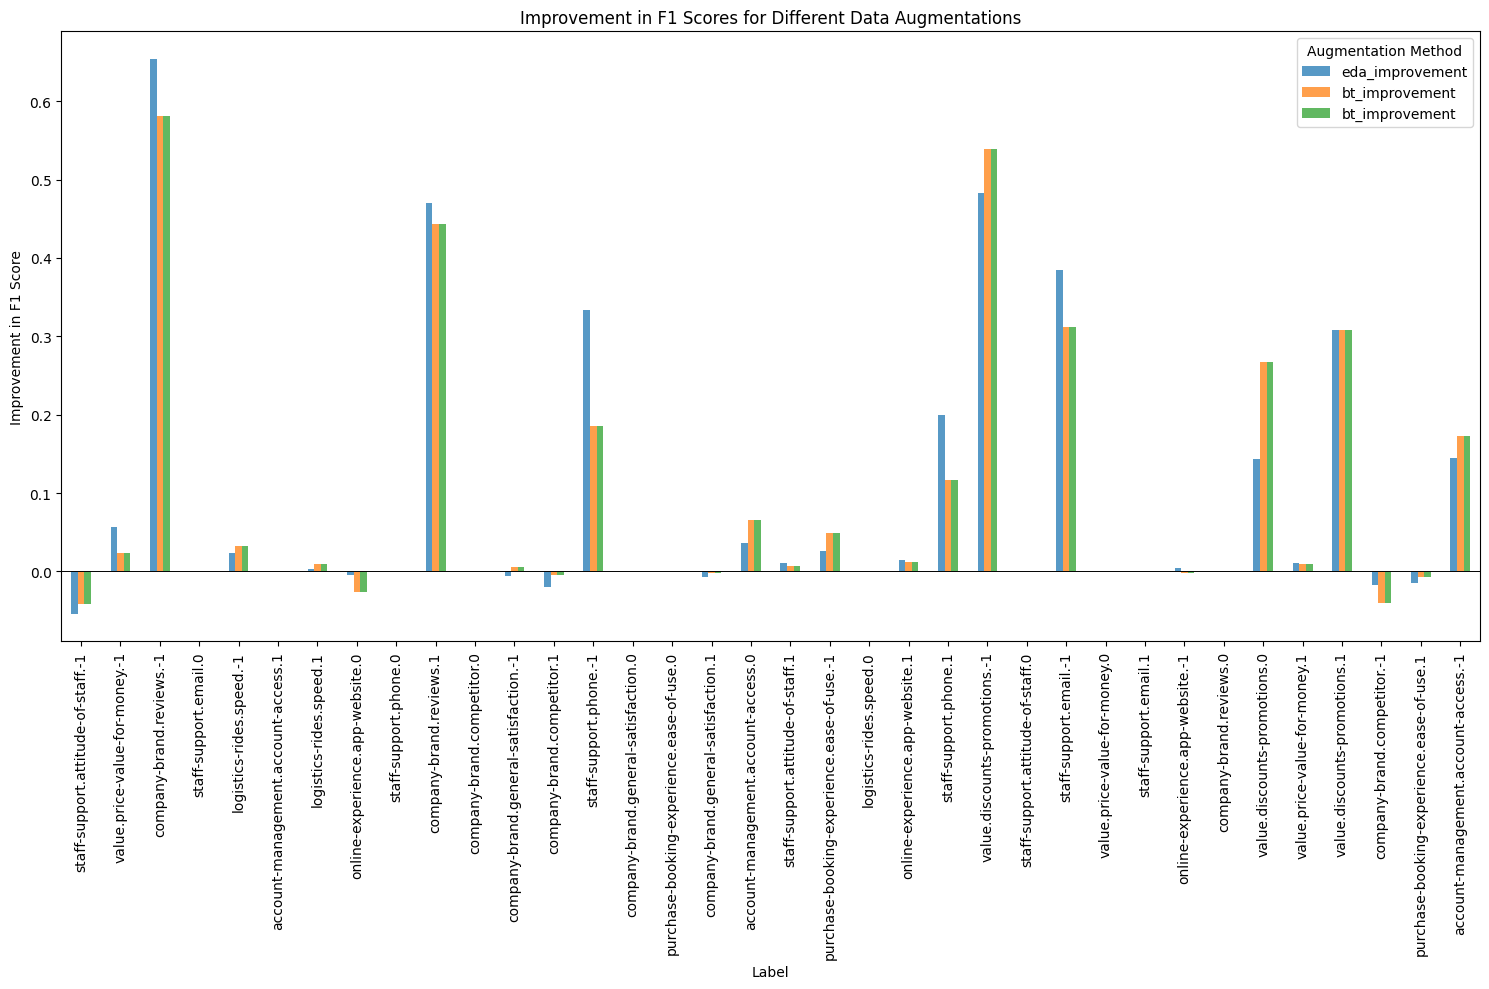

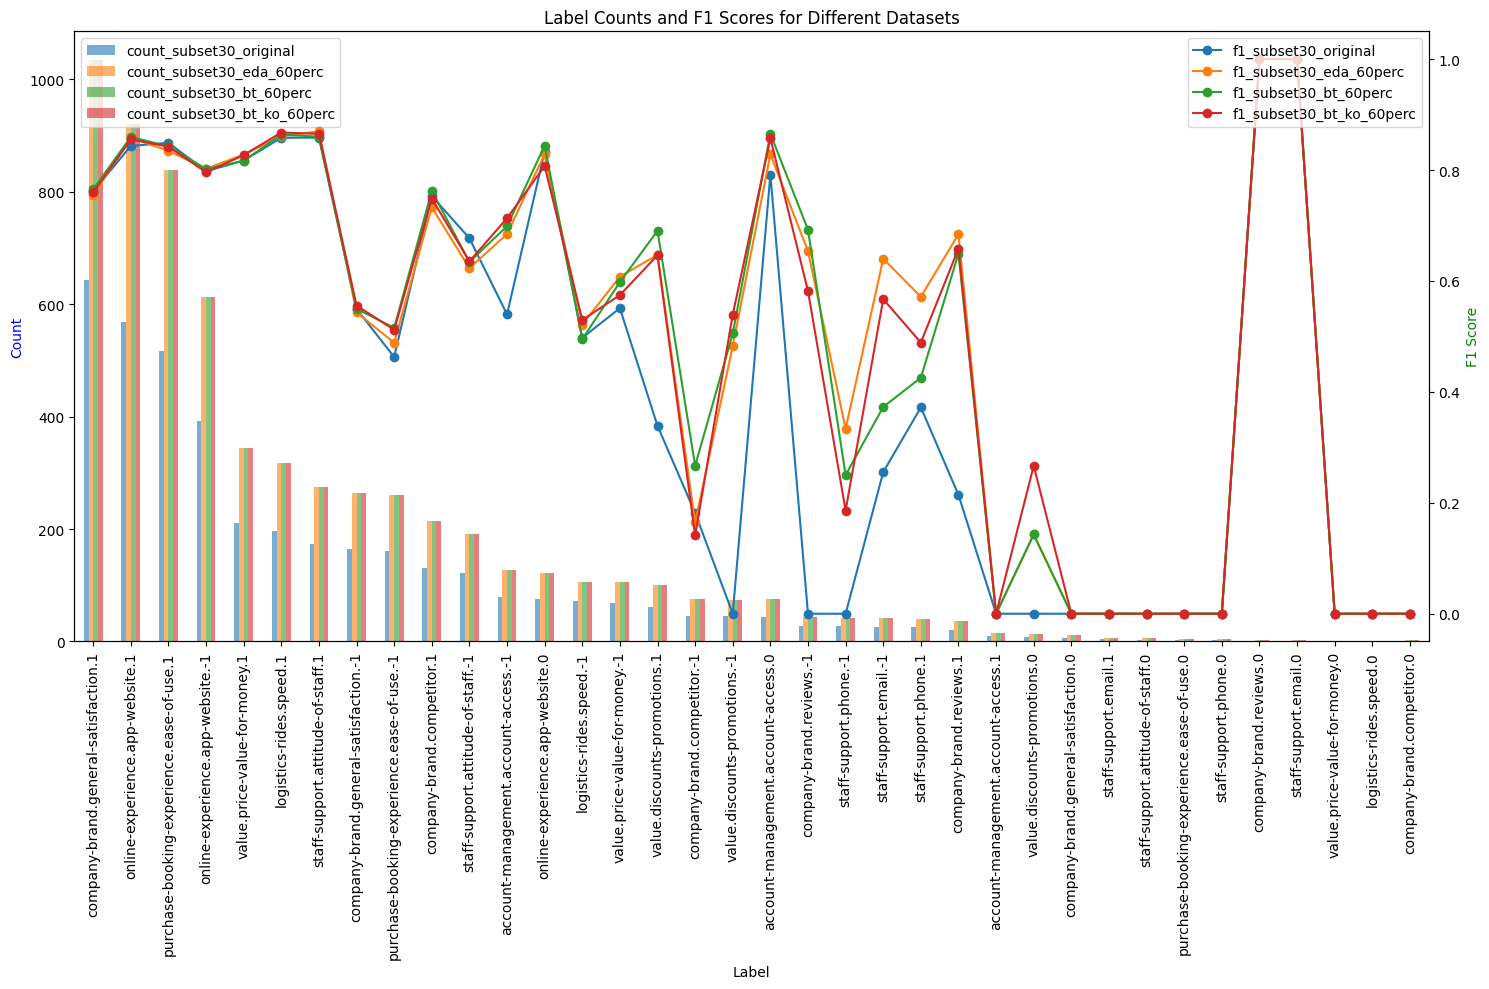

In [ ]:
dataset_files = {
        'subset30_original': "/content/gdrive/My Drive/MSc Project/train_subset30.csv",
        'subset30_eda_60perc': "/content/gdrive/My Drive/MSc Project/subset30_eda_60.0.csv",
        'subset30_bt_60perc': "/content/gdrive/My Drive/MSc Project/subset30_backtrans_60.csv",
        'subset30_bt_ko_60perc': "/content/gdrive/My Drive/MSc Project/subset30_backtrans_ko60.csv"
    }
datasets_list = ["subset30_original", "subset30_eda_60perc", "subset30_bt_60perc", "subset30_bt_ko_60perc"]
model_name = "bertbase"  # or whatever model name you're using
main(datasets_list, model_name, dataset_files)

## Result : Data size and F1 score

Size of data set

In [ ]:
train_df= pd.read_csv('/content/gdrive/My Drive/MSc Project/train_df.csv')
train_subset= pd.read_csv('/content/gdrive/My Drive/MSc Project/train_subset.csv')
train_subset05= pd.read_csv('/content/gdrive/My Drive/MSc Project/train_subset5.csv')
train_subset10= pd.read_csv('/content/gdrive/My Drive/MSc Project/train_subset10.csv')
train_subset20= pd.read_csv('/content/gdrive/My Drive/MSc Project/train_subset20.csv')
train_subset30= pd.read_csv('/content/gdrive/My Drive/MSc Project/train_subset30.csv')

In [ ]:
print(len(train_subset), len(train_subset05), len(train_subset10), len(train_subset20), len(train_subset30), len(train_df))

88 380 750 1517 2247 7401


Load overall result

In [ ]:
subset01_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/Results/Bertbase/subset01/subset01_bertbase.csv')
subset05_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/Results/Bertbase/subset05/subset05_bertbase.csv')
subset10_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/Results/Bertbase/subset10/subset10_bertbase.csv')
subset20_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/Results/Bertbase/subset20/subset20_bertbase.csv')
subset30_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/Results/Bertbase/subset30/subset30_bertbase.csv')
original_bertbase = pd.read_csv('/content/gdrive/My Drive/MSc Project/Results/Bertbase/original/original_bertbase.csv')

In [ ]:
subset01_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,subset01_original,0.087349,0.494942,0.0
1,subset01_eda_60perc,0.112718,0.571285,0.0
2,subset01_bt_60perc,0.112786,0.571410,0.0
3,subset01_bt_ko_60perc,0.112486,0.570439,0.0


In [ ]:
subset05_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,original_subset05,0.598029,0.737561,0.326190
1,subset05_eda_60perc,0.627958,0.762016,0.349196
2,subset05_bt_60perc,0.637576,0.768707,0.364009
3,subset05_bt_ko_60perc,0.631248,0.764383,0.364324


In [ ]:
subset10_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,subset10_original,0.658341,0.778242,0.398361
1,subset10_eda_60perc,0.691321,0.807875,0.420737
2,subset10_bt_60perc,0.695000,0.812955,0.432714
3,subset10_bt_ko_60perc,0.685821,0.805893,0.423259


In [ ]:
subset20_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,subset20_original,0.718565,0.825922,0.458557
1,subset20_eda_60perc,0.735596,0.846446,0.477781
2,subset20_bt_60perc,0.740191,0.850414,0.484715
3,subset20_bt_ko_60perc,0.733464,0.844272,0.482509


In [ ]:
subset30_bertbase

,dataset_key,eval_f1,eval_roc_auc,eval_accuracy
0,subset30_original,0.741417,0.843009,0.488497
1,subset30_eda_60perc,0.754371,0.858445,0.499842
2,subset30_bt_60perc,0.757856,0.860552,0.503939
3,subset30_bt_ko_60perc,0.754689,0.860669,0.503624


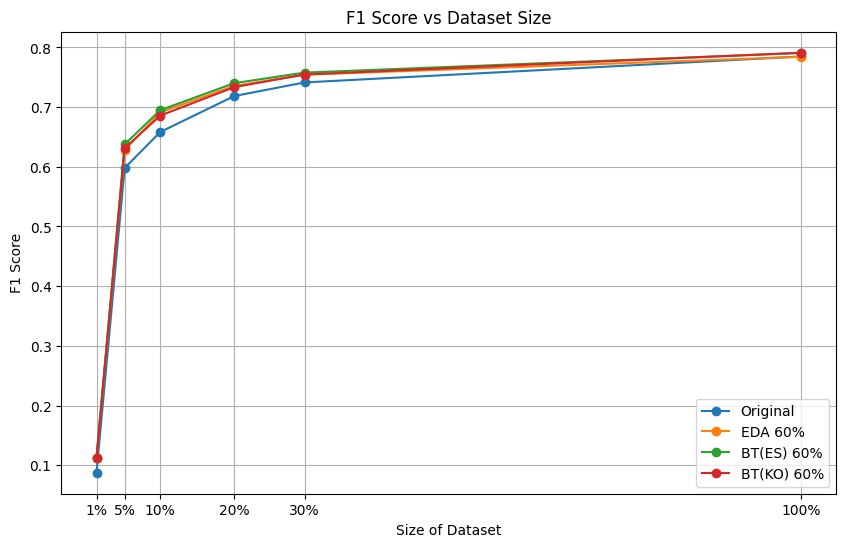

In [ ]:
# Dataset sizes
sizes = [88, 380, 750, 1517, 2247, 7401]
percentage_labels = ["1%", "5%", "10%", "20%", "30%", "100%"]
datasets = {
    'original': [subset01_bertbase, subset05_bertbase, subset10_bertbase, subset20_bertbase, subset30_bertbase, original_bertbase]
}

# Extracting F1 scores for each method across the different dataset sizes
f1_scores_original = [df.iloc[0]['eval_f1'] for df in datasets['original']]
f1_scores_eda = [df.iloc[1]['eval_f1'] for df in datasets['original']]
f1_scores_bt = [df.iloc[2]['eval_f1'] for df in datasets['original']]
f1_scores_bt_ko = [df.iloc[3]['eval_f1'] for df in datasets['original']]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sizes, f1_scores_original, '-o', label='Original')
plt.plot(sizes, f1_scores_eda, '-o', label='EDA 60%')
plt.plot(sizes, f1_scores_bt, '-o', label='BT(ES) 60%')
plt.plot(sizes, f1_scores_bt_ko, '-o', label='BT(KO) 60%')

plt.xlabel('Size of Dataset')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Dataset Size')
plt.xticks(sizes, percentage_labels)  # Setting custom x-axis ticks
plt.legend()
plt.grid(True)
plt.show()


## Correlation : Overall

In [ ]:
f1_increment_eda = [eda - orig for eda, orig in zip(f1_scores_eda, f1_scores_original)]
f1_increment_bt = [bt - orig for bt, orig in zip(f1_scores_bt, f1_scores_original)]
f1_increment_bt_ko = [bt - orig for bt, orig in zip(f1_scores_bt_ko, f1_scores_original)]

In [ ]:
f1_increment_eda

[0.02536878453999561,
 0.029928898900448475,
 0.03298036049783215,
 0.017030552332100046,
 0.012954333902283954,
 -0.0005181484585403684]

In [ ]:
f1_increment_bt

[0.025437103483097412,
 0.0395460575220119,
 0.036658374107088165,
 0.02162588057849202,
 0.016438799250784286,
 0.005817393472822174]

In [ ]:
f1_increment_bt_ko

[0.025137297099907904,
 0.03321858762796215,
 0.027479977296285596,
 0.014899112786771251,
 0.01327220067935675,
 0.006295803141800227]

In [ ]:
# For Original vs EDA60%
corr_eda, _ = pearsonr(sizes, f1_increment_eda)

# For Original vs BT60%
corr_bt, _ = pearsonr(sizes, f1_increment_bt)

# For Original vs BT60%
corr_bt_ko, _ = pearsonr(sizes, f1_increment_bt_ko)

print("Pearson correlation coefficient for Original vs EDA60%:", corr_eda)
print("Pearson correlation coefficient for Original vs BT60% (Spanish):", corr_bt)
print("Pearson correlation coefficient for Original vs BT60% (Korean):", corr_bt_ko)



Pearson correlation coefficient for Original vs EDA60%: -0.9036457390508255
Pearson correlation coefficient for Original vs BT60% (Spanish): -0.8282702071927742
Pearson correlation coefficient for Original vs BT60% (Korean): -0.8204967829883351


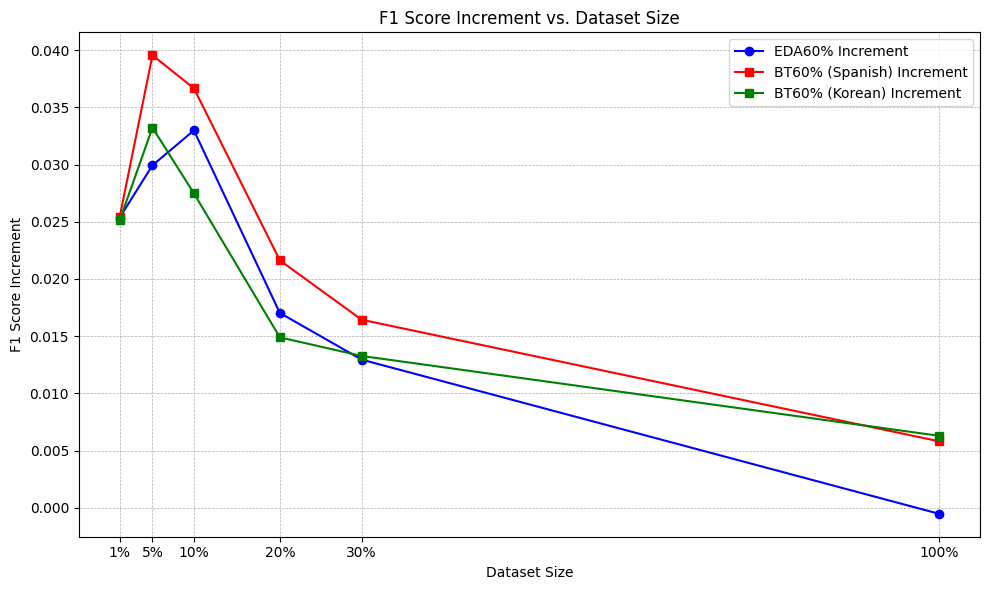

In [ ]:
plt.figure(figsize=(10, 6))

# Plot for EDA60%
plt.plot(sizes, f1_increment_eda, 'o-', label='EDA60% Increment', color='blue')
# Plot for BT60%
plt.plot(sizes, f1_increment_bt, 's-', label='BT60% (Spanish) Increment', color='red')
# Plot for BT60%
plt.plot(sizes, f1_increment_bt_ko, 's-', label='BT60% (Korean) Increment', color='green')

# Add legends, title, and axis labels
plt.legend()
plt.title('F1 Score Increment vs. Dataset Size')
plt.xlabel('Dataset Size')
plt.ylabel('F1 Score Increment')
plt.xticks(sizes, ['1%', '5%', '10%', '20%', '30%', '100%'])  # Using the given percentage annotations
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()
